In [1]:
%%capture
%pip install pandas numpy evaluate matplotlib seaborn tqdm nltk spacy torch transformers bert-score rouge_score sentence-transformers scikit-learn

## **Ship of the Theseus: A Forensic Study of Stylistic and Semantic Drift of Text Corpus Withstanding LLM Paraphrasing**
Team 3: Liang Yingzi, Hou Jingwen and Wang Yunchen

## Table of Contents

---
Part 1: Stylistic vs. Semantic Drift
- Cell 14: Calculating Semantic Metrics
- Cell 21: Calculating Stylistic Metrics
- Cell 24: Comparison and Interpretation - Style vs. Content Drift

---
Part 2: The Point of No Return
- Cell 30: Sanity check: POS-tag Frequencies and Dependency Tree Depth (T0 to T3)
- Cell 35: Visualization and Interpretation of POS tag and Dependency
- Cell 38: **Task** - Authorship Attribution
- Cell 42: Ablation Study - Authorship Attribution
- Cell 46: **Task** - Preliminary Paraphraser Fingerprints
- Cell 50: Ablation Study - Paraphraser Fingerprints

## Part 0: Data cleansing and Pre-Processing

In [2]:
# download required NLP librarie and detect the current compute device
import re
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

import nltk

try:
    nltk.data.find("tokenizers/punkt")
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("punkt")
    nltk.download("stopwords")

import torch

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Current Device: {device}")

Current Device: cuda


In [ ]:
csv_path = "dataset/yelp_paraphrased.csv"
df = pd.read_csv(csv_path)

print(df.head())

        source       key                                               text  \
0         PaLM  yelp-494  sorry to say I did not have a good experience ...   
1   BigScience  yelp-494  sorry to say I did not have a good experience ...   
2        LLAMA  yelp-494  sorry to say I did not have a good experience ...   
3  Eleuther-AI  yelp-494  sorry to say I did not have a good experience ...   
4       OpenAI  yelp-494  sorry to say I did not have a good experience ...   

  version_name  
0     original  
1     original  
2     original  
3     original  
4     original  


In [4]:
# Check how many distinct values in the `version_name`
print("All version names:", df["version_name"].unique())
print("\nCounts per version name:")
print(df["version_name"].value_counts())

All version names: <ArrowStringArray>
[                                       'original',
                                       'palm_palm',
                                 'chatgpt_chatgpt',
                                            'palm',
                                         'chatgpt',
                                  'palm_palm_palm',
                         'chatgpt_chatgpt_chatgpt',
                                 'pegasus(slight)',
                                   'pegasus(full)',
                     'pegasus(full)_pegasus(full)',
       'pegasus(full)_pegasus(full)_pegasus(full)',
                 'pegasus(slight)_pegasus(slight)',
 'pegasus(slight)_pegasus(slight)_pegasus(slight)',
                                          'dipper',
                                   'dipper_dipper',
                            'dipper_dipper_dipper',
                                     'dipper(low)',
                         'dipper(low)_dipper(low)',
             'dipper(low)_

In [5]:
def parse_version(v_name, source):
    v_name = str(v_name)

    # original belongs to its own source chain (Human/OpenAI/PaLM/...)
    if v_name == "original":
        return 0, str(source)

    parts = v_name.split("_")
    depth = len(parts)

    # model_group from the first token, normalize "dipper(low)" -> "dipper"
    base = re.sub(r"\(.*?\)", "", parts[0]).strip()
    return depth, base


df[["depth", "model_group"]] = df.apply(
    lambda r: pd.Series(parse_version(r["version_name"], r["source"])), axis=1
)

print(
    df[["source", "version_name", "depth", "model_group"]]
    .drop_duplicates()
    .sort_values(["model_group", "depth", "version_name"])
    .reset_index(drop=True)
    .head(50)
)

         source               version_name  depth  model_group
0    BigScience                   original      0   BigScience
1   Eleuther-AI                   original      0  Eleuther-AI
2         Human                   original      0        Human
3         LLAMA                   original      0        LLAMA
4        OpenAI                   original      0       OpenAI
5          PaLM                   original      0         PaLM
6      Tsinghua                   original      0     Tsinghua
7          PaLM                    chatgpt      1      chatgpt
8    BigScience                    chatgpt      1      chatgpt
9         LLAMA                    chatgpt      1      chatgpt
10  Eleuther-AI                    chatgpt      1      chatgpt
11     Tsinghua                    chatgpt      1      chatgpt
12        Human                    chatgpt      1      chatgpt
13       OpenAI                    chatgpt      1      chatgpt
14         PaLM            chatgpt_chatgpt      2      

In [6]:
# Define a text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


df["text_cleaned"] = df["text"].apply(clean_text)

print("Cleaning examples:")
for _ in range(3):
    sample = df.sample(1).iloc[0]
    print(f"[Original] {str(sample['text'])[:100]}...")
    print(f"[Cleaned ] {str(sample['text_cleaned'])[:100]}...\n")

Cleaning examples:
[Original] Although this establishment is not ideal for medical care, as evidenced by the two-hour wait for tes...
[Cleaned ] although this establishment is not ideal for medical care, as evidenced by the two-hour wait for tes...

[Original] Before I begin, I want to mention that I received the all-day buffet at no cost, which typically cos...
[Cleaned ] before i begin, i want to mention that i received the all-day buffet at no cost, which typically cos...

[Original]  The long overdue review. The kimchi fried rice is a must!!! Anything with kimchi is good. I would d...
[Cleaned ] the long overdue review. the kimchi fried rice is a must!!! anything with kimchi is good. i would de...



In [7]:
# [Checklist 1] Corpus ingestion: identify corpus subset from the key prefix
# Assumption: key format is "dataset-id" (e.g., "yelp-123")

df["dataset_name"] = df["key"].apply(lambda x: x.split("-")[0])
print("Corpus subsets in this dataset:", df["dataset_name"].unique())

Corpus subsets in this dataset: <ArrowStringArray>
['yelp']
Length: 1, dtype: str


In [8]:
# Data alignment: attach the original human text (T0) as the reference for each row
df_human = (
    df[(df["version_name"] == "original") & (df["source"] == "Human")][
        ["key", "text_cleaned"]
    ]
    .drop_duplicates(subset=["key"])
    .rename(columns={"text_cleaned": "human_ref"})
)

df_eval = pd.merge(df, df_human, on="key", how="left")
df_eval = df_eval.dropna(subset=["human_ref"])

print(f"Aligned. Rows for evaluation: {len(df_eval)}")
print(df_eval[["model_group", "depth", "text_cleaned", "human_ref"]].head(2))

Aligned. Rows for evaluation: 72847
  model_group  depth                                       text_cleaned  \
0        PaLM      0  sorry to say i did not have a good experience ...   
1  BigScience      0  sorry to say i did not have a good experience ...   

                                           human_ref  
0  sorry to say i did not have a good experience ...  
1  sorry to say i did not have a good experience ...  


In [9]:
# Remove duplicate by ("key", "model_group", "depth")
dedup_keys = ["key", "model_group", "depth"]

eval_pairs = (
    df_eval.loc[
        df_eval["depth"].isin([1, 2, 3]), dedup_keys + ["text_cleaned", "human_ref"]
    ]
    .drop_duplicates(subset=dedup_keys)
    .copy()
)

print("rows(df_eval)   =", len(df_eval))
print("rows(eval_pairs)=", len(eval_pairs))
print("dup in eval_pairs =", eval_pairs.duplicated(subset=dedup_keys).sum())

rows(df_eval)   = 72847
rows(eval_pairs)= 5892
dup in eval_pairs = 0


## Part 1: Stylistic vs. Semantic Drift

#### Semantic Metrics

In [10]:
# ROUGE-L
import evaluate
from tqdm.auto import tqdm

tqdm.pandas()

rouge_metric = evaluate.load("rouge")


def calc_rouge_l(row):
    pred = str(row["text_cleaned"])
    ref = str(row["human_ref"])
    if not pred or not ref:
        return 0.0
    return float(rouge_metric.compute(predictions=[pred], references=[ref], use_stemmer=True)["rougeL"])  # type: ignore


print("Computing rouge_l...")
eval_pairs["rouge_l"] = eval_pairs.progress_apply(calc_rouge_l, axis=1)

eval_pairs[["key", "model_group", "depth", "rouge_l"]].head()

/home/mack/Anaconda/envs/cs6120/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing rouge_l...


100%|██████████| 5892/5892 [04:17<00:00, 22.88it/s]


,key,model_group,depth,rouge_l
3320,yelp-494,palm,2,0.180723
3321,yelp-495,palm,2,0.285714
3322,yelp-496,palm,2,0.296774
3323,yelp-497,palm,2,0.303030
3324,yelp-498,palm,2,0.268041


In [11]:
# Calculate BLEU
from tqdm.auto import tqdm

tqdm.pandas()

bleu_metric = evaluate.load("bleu")


def calc_bleu(row):
    pred = str(row["text_cleaned"])
    ref = str(row["human_ref"])
    if not pred or not ref:
        return 0.0
    # evaluate BLEU API: predictions=[...], references=[[...]]
    return float(bleu_metric.compute(predictions=[pred], references=[[ref]])["bleu"])  # type: ignore


print("Computing BLEU ...")
eval_pairs["bleu"] = eval_pairs.progress_apply(calc_bleu, axis=1)

eval_pairs[["key", "model_group", "depth", "bleu"]].head()

Computing BLEU ...


100%|██████████| 5892/5892 [00:12<00:00, 454.16it/s]


,key,model_group,depth,bleu
3320,yelp-494,palm,2,0.007191
3321,yelp-495,palm,2,0.086171
3322,yelp-496,palm,2,0.103998
3323,yelp-497,palm,2,0.099250
3324,yelp-498,palm,2,0.000000


In [12]:
# Calculate BERTScore
import torch
import numpy as np
from bert_score import score

# pick device
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print("device =", device)

cands = eval_pairs["text_cleaned"].astype(str).tolist()
refs = eval_pairs["human_ref"].astype(str).tolist()

print("Computing BERTScore...")
P, R, F1 = score(
    cands,
    refs,
    lang="en",
    model_type="roberta-base",
    device=device,
    batch_size=32,
    rescale_with_baseline=True,
    verbose=True,
)

eval_pairs["bert_score"] = F1.detach().cpu().numpy()
eval_pairs[["key", "model_group", "depth", "bert_score"]].head()

device = cuda
Computing BERTScore...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5736.05it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 199/199 [00:29<00:00,  6.74it/s]


computing greedy matching.


100%|██████████| 185/185 [00:01<00:00, 112.02it/s]


done in 31.34 seconds, 188.00 sentences/sec


/home/mack/Anaconda/envs/cs6120/lib/python3.12/site-packages/bert_score/score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  baselines = torch.from_numpy(


,key,model_group,depth,bert_score
3320,yelp-494,palm,2,0.370073
3321,yelp-495,palm,2,0.501134
3322,yelp-496,palm,2,0.447381
3323,yelp-497,palm,2,0.408251
3324,yelp-498,palm,2,0.445927


In [13]:
# Save similarity baseline table (BLEU + ROUGE-L + BERTScore) per paraphraser & depth
baseline_table = (
    eval_pairs.groupby(["model_group", "depth"], as_index=False)
    .agg(
        n=("key", "count"),
        bleu_mean=("bleu", "mean"),
        rouge_l_mean=("rouge_l", "mean"),
        bert_score_mean=("bert_score", "mean"),
    )
    .sort_values(["model_group", "depth"])
)

baseline_table.to_csv("similarity_baseline_table.csv", index=False)
print("Saved: similarity_baseline_table.csv")
baseline_table

Saved: similarity_baseline_table.csv


,model_group,depth,n,bleu_mean,rouge_l_mean,bert_score_mean
0,chatgpt,1,491,0.046973,0.223775,0.279492
1,chatgpt,2,491,0.049969,0.219643,0.251389
2,chatgpt,3,491,0.036139,0.202690,0.236833
3,dipper,1,491,0.056831,0.204210,0.228244
4,dipper,2,491,0.030278,0.187413,0.198968
5,dipper,3,491,0.019840,0.165477,0.172760
6,palm,1,491,0.057586,0.228741,0.246936
7,palm,2,491,0.036290,0.199843,0.222240
8,palm,3,491,0.031321,0.189882,0.213080
9,pegasus,1,491,0.270706,0.388039,0.388001


In [14]:
# Linguistic Delta
# Compute sbert cosine
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer("all-MiniLM-L6-v2")


tqdm.pandas()

# 1) Encode unique texts only (faster)
all_texts = pd.concat(
    [eval_pairs["human_ref"], eval_pairs["text_cleaned"]], axis=0
).astype(str)
uniq_texts = all_texts.drop_duplicates().tolist()

emb = sbert.encode(
    uniq_texts,
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,  # so dot(a,b) == cosine(a,b)
)
text2emb = dict(zip(uniq_texts, emb))


# 2) Row-wise cosine similarity (T0 vs Tx)
def sbert_cosine(row):
    a = text2emb[str(row["human_ref"])]
    b = text2emb[str(row["text_cleaned"])]
    return float(np.dot(a, b))


print("Computing sbert_cosine...")
eval_pairs["sbert_cosine"] = eval_pairs.progress_apply(sbert_cosine, axis=1)

eval_pairs[["key", "model_group", "depth", "sbert_cosine"]].head()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16320.87it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 50/50 [00:04<00:00, 11.04it/s]


Computing sbert_cosine...


100%|██████████| 5892/5892 [00:00<00:00, 209170.26it/s]


,key,model_group,depth,sbert_cosine
3320,yelp-494,palm,2,0.753402
3321,yelp-495,palm,2,0.793188
3322,yelp-496,palm,2,0.803911
3323,yelp-497,palm,2,0.805108
3324,yelp-498,palm,2,0.633136


In [15]:
# Quick summary table for SBERT cosine (Semantic Hull) per paraphraser & depth
sbert_table = (
    eval_pairs.groupby(["model_group", "depth"], as_index=False)
    .agg(
        n=("key", "count"),
        sbert_cosine_mean=("sbert_cosine", "mean"),
        sbert_cosine_median=("sbert_cosine", "median"),
    )
    .sort_values(["model_group", "depth"])
)

sbert_table.to_csv("linguistic_delta_sbert_table.csv", index=False)
print("Saved: linguistic_delta_sbert_table.csv")
sbert_table

Saved: linguistic_delta_sbert_table.csv


,model_group,depth,n,sbert_cosine_mean,sbert_cosine_median
0,chatgpt,1,491,0.657523,0.686472
1,chatgpt,2,491,0.654293,0.681140
2,chatgpt,3,491,0.644155,0.662126
3,dipper,1,491,0.610671,0.619022
4,dipper,2,491,0.569947,0.581317
5,dipper,3,491,0.538804,0.549994
6,palm,1,491,0.644895,0.664145
7,palm,2,491,0.627499,0.648117
8,palm,3,491,0.624597,0.639322
9,pegasus,1,491,0.722429,0.730977


#### Stylistic Metrics

In [16]:
# Plank
tqdm.pandas()

word_re = re.compile(r"[A-Za-z0-9']+")
punct_re = re.compile(r"[^\w\s]")


def plank_feats(text: str):
    text = str(text)
    tokens = word_re.findall(text.lower())
    n_tokens = len(tokens)

    # 1) length: #tokens
    tok_len = n_tokens

    # 2) TTR: type-token ratio
    ttr = (len(set(tokens)) / n_tokens) if n_tokens > 0 else 0.0

    # 3) avg word length
    avg_word_len = (sum(len(t) for t in tokens) / n_tokens) if n_tokens > 0 else 0.0

    # 4) punctuation ratio
    n_punct = len(punct_re.findall(text))
    punct_ratio = n_punct / max(len(text), 1)

    return pd.Series(
        {
            "tok_len": tok_len,
            "ttr": ttr,
            "avg_word_len": avg_word_len,
            "punct_ratio": punct_ratio,
        }
    )


print("Extracting plank features for T0 (human_ref)...")
ref_feats = eval_pairs["human_ref"].progress_apply(plank_feats).add_prefix("ref_")

print("Extracting plank features for Tx (text_cleaned)...")
cand_feats = eval_pairs["text_cleaned"].progress_apply(plank_feats).add_prefix("cand_")

eval_pairs = pd.concat([eval_pairs, ref_feats, cand_feats], axis=1)

# deltas: Tx - T0
for c in ["tok_len", "ttr", "avg_word_len", "punct_ratio"]:
    eval_pairs[f"delta_{c}"] = eval_pairs[f"cand_{c}"] - eval_pairs[f"ref_{c}"]

eval_pairs[
    [
        "key",
        "model_group",
        "depth",
        "delta_tok_len",
        "delta_ttr",
        "delta_avg_word_len",
        "delta_punct_ratio",
    ]
].head()

Extracting plank features for T0 (human_ref)...


100%|██████████| 5892/5892 [00:00<00:00, 10374.42it/s]


Extracting plank features for Tx (text_cleaned)...


100%|██████████| 5892/5892 [00:00<00:00, 7803.06it/s] 


,key,model_group,depth,delta_tok_len,delta_ttr,delta_avg_word_len,delta_punct_ratio
3320,yelp-494,palm,2,-99.0,0.148378,0.197281,0.001268
3321,yelp-495,palm,2,9.0,0.071429,-0.156085,-0.015238
3322,yelp-496,palm,2,5.0,-0.128732,0.455392,0.008249
3323,yelp-497,palm,2,25.0,-0.198344,-0.137751,-0.002157
3324,yelp-498,palm,2,-38.0,0.204323,0.964488,0.002145


In [17]:
# Planks: aggregate delta features by (model_group x depth)

delta_cols = ["delta_tok_len", "delta_ttr", "delta_avg_word_len", "delta_punct_ratio"]

planks_table = (
    eval_pairs.groupby(["model_group", "depth"], as_index=False)
    .agg(
        n=("key", "count"),
        **{f"{c}_mean": (c, "mean") for c in delta_cols},
        **{f"{c}_median": (c, "median") for c in delta_cols},
        **{
            f"{c}_abs_mean": (c, lambda x: float(np.mean(np.abs(x))))
            for c in delta_cols
        },
    )
    .sort_values(["model_group", "depth"])
)

planks_table.to_csv("planks_lexical_delta_table.csv", index=False)
print("Saved: planks_lexical_delta_table.csv")
planks_table

Saved: planks_lexical_delta_table.csv


,model_group,depth,n,delta_tok_len_mean,delta_ttr_mean,delta_avg_word_len_mean,delta_punct_ratio_mean,delta_tok_len_median,delta_ttr_median,delta_avg_word_len_median,delta_punct_ratio_median,delta_tok_len_abs_mean,delta_ttr_abs_mean,delta_avg_word_len_abs_mean,delta_punct_ratio_abs_mean
0,chatgpt,1,491,-4.615071,-0.007533,0.653835,-0.007090,-4.0,0.000000,0.630968,-0.004672,44.069246,0.075794,0.709330,0.011655
1,chatgpt,2,491,38.130346,-0.028791,0.597341,-0.007097,9.0,-0.007018,0.599859,-0.004535,88.940937,0.108436,0.642336,0.011441
2,chatgpt,3,491,35.657841,-0.023913,0.692617,-0.007559,9.0,0.000000,0.693123,-0.004792,88.089613,0.108339,0.726290,0.011488
3,dipper,1,491,64.486762,-0.093551,-0.120611,0.003699,5.0,-0.055516,-0.107043,0.004007,132.050916,0.157433,0.308631,0.011956
4,dipper,2,491,44.576375,-0.089058,-0.135293,0.004065,0.0,-0.056219,-0.129245,0.003494,119.264766,0.152762,0.318992,0.012354
5,dipper,3,491,28.228106,-0.078725,-0.137374,0.005214,-4.0,-0.054578,-0.136767,0.004801,110.435845,0.149708,0.335225,0.013380
6,palm,1,491,-48.148676,0.018215,0.325005,-0.005615,-22.0,0.014877,0.355904,-0.003908,79.692464,0.112400,0.457051,0.012016
7,palm,2,491,-50.782077,0.017548,0.368975,-0.007172,-22.0,0.012543,0.406926,-0.005347,78.900204,0.111841,0.482934,0.012468
8,palm,3,491,-51.321792,0.016914,0.382737,-0.007699,-23.0,0.012153,0.407270,-0.005551,78.507128,0.111801,0.495094,0.012230
9,pegasus,1,491,80.462322,-0.048252,0.038618,-0.001601,2.0,-0.003333,0.016043,-0.000665,145.843177,0.169562,0.307024,0.008461


#### Comparision and Intepretation: Style vs. Content Drift

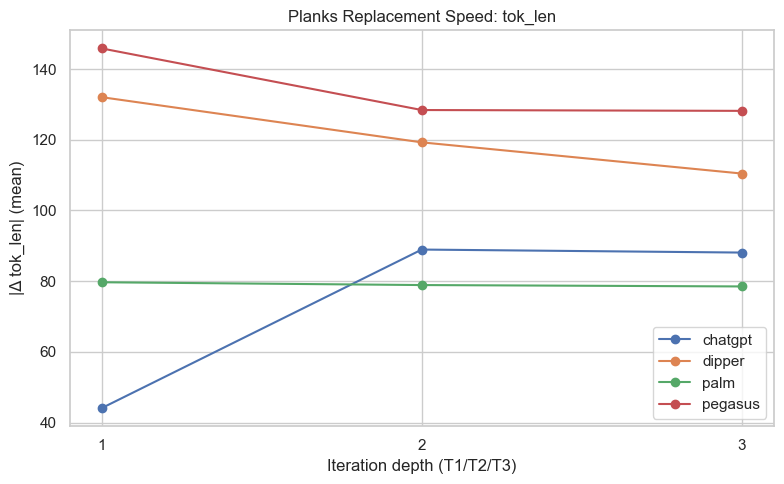

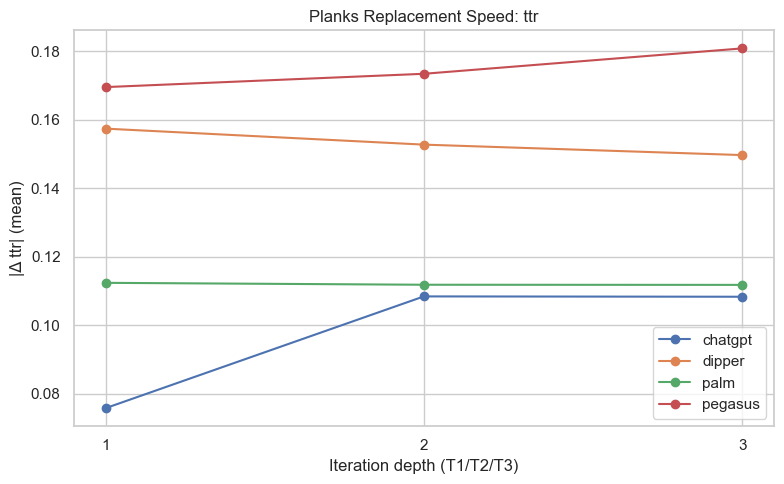

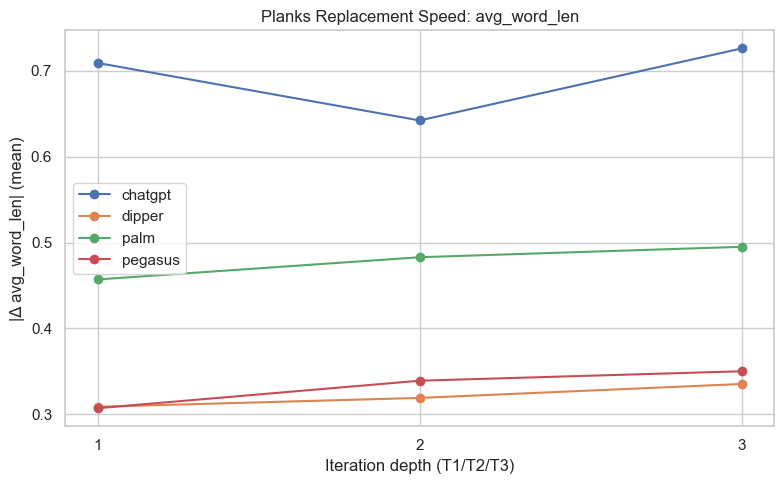

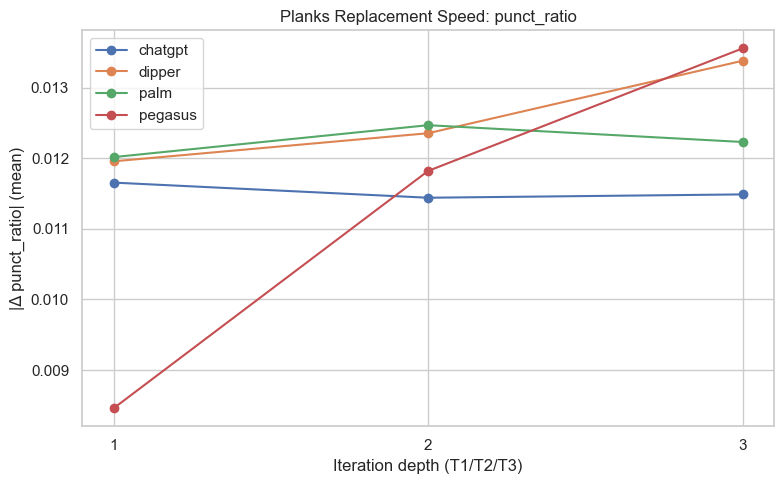

In [18]:
# Planks speed plot: how fast lexical features drift across T1/T2/T3
import matplotlib.pyplot as plt

# Use absolute mean drift as "replacement speed" (magnitude of change)
plot_df = planks_table.copy()

for feat in ["tok_len", "ttr", "avg_word_len", "punct_ratio"]:
    col = f"delta_{feat}_abs_mean"
    plt.figure(figsize=(8, 5))
    for mg in sorted(plot_df["model_group"].unique()):
        sub = plot_df[plot_df["model_group"] == mg].sort_values("depth")
        plt.plot(sub["depth"], sub[col], marker="o", label=mg)
    plt.xticks([1, 2, 3])
    plt.xlabel("Iteration depth (T1/T2/T3)")
    plt.ylabel(f"|Δ {feat}| (mean)")
    plt.title(f"Planks Replacement Speed: {feat}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Per-feature style scaling used:
  delta_tok_len_abs_mean: std=28.693849
  delta_ttr_abs_mean: std=0.032033
  delta_avg_word_len_abs_mean: std=0.151762
  delta_punct_ratio_abs_mean: std=0.001220

Decay and speed table:


,depth,style_decay,content_decay,style_decay_rel,content_decay_rel,style_speed_rel,content_speed_rel,speed_diff_rel_style_minus_content
0,1,4.873012,0.341121,0.000000,0.000000,0.000000,0.000000,0.0000
1,2,5.169451,0.372618,0.637912,0.689611,0.637912,0.689611,-0.0517
2,3,5.337714,0.386795,1.000000,1.000000,0.362088,0.310389,0.0517


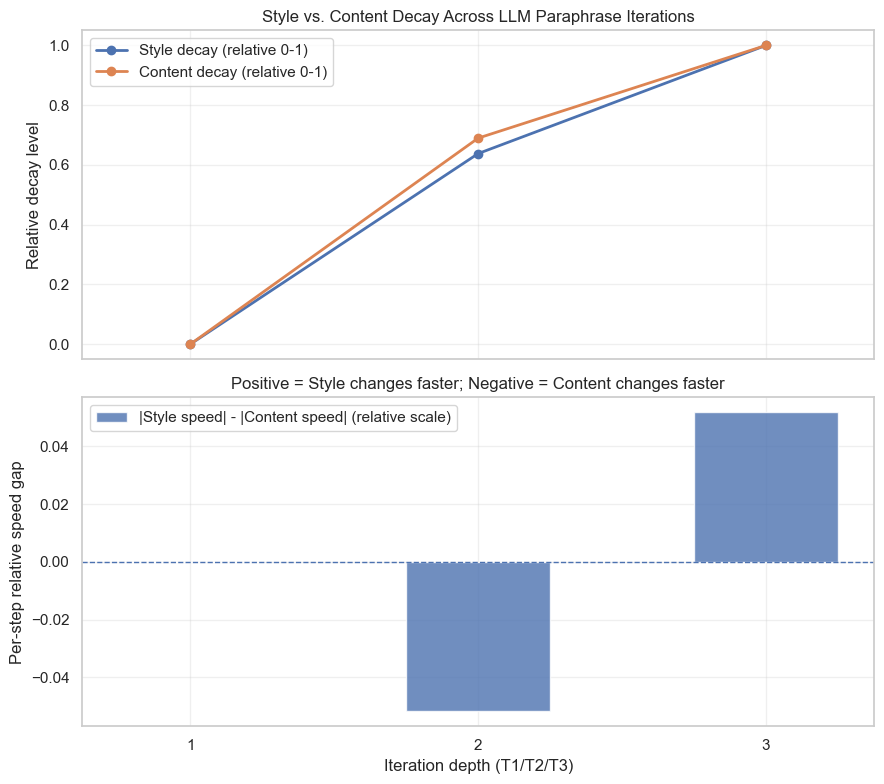

In [19]:
### Style vs. Content Decay Speed Across Iterations
### Relative-comparable style/content decay on a shared [0, 1] scale

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# helper: min-max to [0, 1]
# -----------------------------
def minmax01(s):
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if abs(mx - mn) < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)


# -----------------------------
# 1. Content decay from semantic retention (SBERT cosine)
# -----------------------------
content_by_depth = (
    eval_pairs.groupby("depth", as_index=False)["sbert_cosine"]
    .mean()
    .sort_values("depth")
    .rename(columns={"sbert_cosine": "content_retention"})
)

# higher decay = lower semantic retention
content_by_depth["content_decay"] = 1 - content_by_depth["content_retention"]

# -----------------------------
# 2. Style decay from lexical drift (absolute deltas from T0)
# -----------------------------
style_abs_cols = [
    "delta_tok_len_abs_mean",
    "delta_ttr_abs_mean",
    "delta_avg_word_len_abs_mean",
    "delta_punct_ratio_abs_mean",
]

# copy table so we do not overwrite the original
style_scaled = planks_table.copy()

# scale each style feature separately
scaled_cols = []
for col in style_abs_cols:
    col_std = float(style_scaled[col].std(ddof=0))
    if col_std < 1e-12:
        col_std = 1.0
    scaled_col = col + "_scaled"
    style_scaled[scaled_col] = style_scaled[col] / col_std
    scaled_cols.append(scaled_col)

# aggregate scaled style drift by depth
style_by_depth = (
    style_scaled.groupby("depth", as_index=False)[scaled_cols]
    .mean()
    .sort_values("depth")
)

# overall style decay = average normalized drift across style planks
style_by_depth["style_decay"] = style_by_depth[scaled_cols].mean(axis=1)

# optional raw mean drift for inspection
style_by_depth["style_drift_raw_mean"] = (
    style_scaled.groupby("depth")[style_abs_cols].mean().mean(axis=1).values
)

# -----------------------------
# 3. Merge style and content decay
# -----------------------------
decay_df = pd.merge(
    content_by_depth[["depth", "content_decay"]],
    style_by_depth[["depth", "style_decay", "style_drift_raw_mean"]],
    on="depth",
    how="inner",
).sort_values("depth")

# -----------------------------
# 4. Put style and content on the same [0, 1] relative scale
# -----------------------------
decay_df["style_decay_rel"] = minmax01(decay_df["style_decay"])
decay_df["content_decay_rel"] = minmax01(decay_df["content_decay"])

# -----------------------------
# 5. Per-step relative speed
#    T1 speed is measured relative to T0 baseline = 0
# -----------------------------
decay_df["content_speed_rel"] = decay_df["content_decay_rel"].diff()
decay_df["style_speed_rel"] = decay_df["style_decay_rel"].diff()

if len(decay_df) > 0:
    first_idx = decay_df.index[0]
    decay_df.loc[first_idx, "content_speed_rel"] = decay_df.loc[
        first_idx, "content_decay_rel"
    ]
    decay_df.loc[first_idx, "style_speed_rel"] = decay_df.loc[
        first_idx, "style_decay_rel"
    ]

# compare magnitudes of change on the same scale
decay_df["content_speed_rel"] = decay_df["content_speed_rel"].abs()
decay_df["style_speed_rel"] = decay_df["style_speed_rel"].abs()
decay_df["speed_diff_rel_style_minus_content"] = (
    decay_df["style_speed_rel"] - decay_df["content_speed_rel"]
)

print("Per-feature style scaling used:")
for col in style_abs_cols:
    print(f"  {col}: std={style_scaled[col].std(ddof=0):.6f}")

print("\nDecay and speed table:")
display(
    decay_df[
        [
            "depth",
            "style_decay",
            "content_decay",
            "style_decay_rel",
            "content_decay_rel",
            "style_speed_rel",
            "content_speed_rel",
            "speed_diff_rel_style_minus_content",
        ]
    ]
)

# -----------------------------
# 6. Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Top panel: relative cumulative decay on the same scale
axes[0].plot(
    decay_df["depth"],
    decay_df["style_decay_rel"],
    marker="o",
    linewidth=2,
    label="Style decay (relative 0-1)",
)
axes[0].plot(
    decay_df["depth"],
    decay_df["content_decay_rel"],
    marker="o",
    linewidth=2,
    label="Content decay (relative 0-1)",
)
axes[0].set_ylabel("Relative decay level")
axes[0].set_title("Style vs. Content Decay Across LLM Paraphrase Iterations")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bottom panel: per-step relative speed difference
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].bar(
    decay_df["depth"],
    decay_df["speed_diff_rel_style_minus_content"],
    width=0.5,
    alpha=0.8,
    label="|Style speed| - |Content speed| (relative scale)",
)
axes[1].set_xlabel("Iteration depth (T1/T2/T3)")
axes[1].set_ylabel("Per-step relative speed gap")
axes[1].set_title("Positive = Style changes faster; Negative = Content changes faster")
axes[1].set_xticks(sorted(decay_df["depth"].unique()))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Per-feature style scaling used:
  delta_tok_len_abs_mean: std=28.693849
  delta_ttr_abs_mean: std=0.032033
  delta_avg_word_len_abs_mean: std=0.151762
  delta_punct_ratio_abs_mean: std=0.001220

Per-model decay and speed table:


,model_group,depth,style_decay,content_decay,style_decay_rel,content_decay_rel,style_speed_rel,content_speed_rel,speed_diff_rel_style_minus_content
0,chatgpt,1,4.532685,0.342477,0.000000,0.000000,0.000000,0.000000,0.000000
1,chatgpt,2,5.024169,0.345707,0.778556,0.241675,0.778556,0.241675,0.536880
2,chatgpt,3,5.163961,0.355845,1.000000,1.000000,0.221444,0.758325,-0.536880
3,dipper,1,5.338145,0.389329,0.362049,0.000000,0.362049,0.000000,0.362049
4,dipper,2,5.288830,0.430053,0.000000,0.566660,0.362049,0.566660,-0.204611
5,dipper,3,5.425042,0.461196,1.000000,1.000000,1.000000,0.433340,0.566660
6,palm,1,4.787250,0.355105,0.000000,0.000000,0.000000,0.000000,0.000000
7,palm,2,4.911176,0.372501,1.000000,0.857044,1.000000,0.857044,0.142956
8,palm,3,4.878765,0.375403,0.738468,1.000000,0.261532,0.142956,0.118577
9,pegasus,1,4.833967,0.277571,0.000000,0.000000,0.000000,0.000000,0.000000


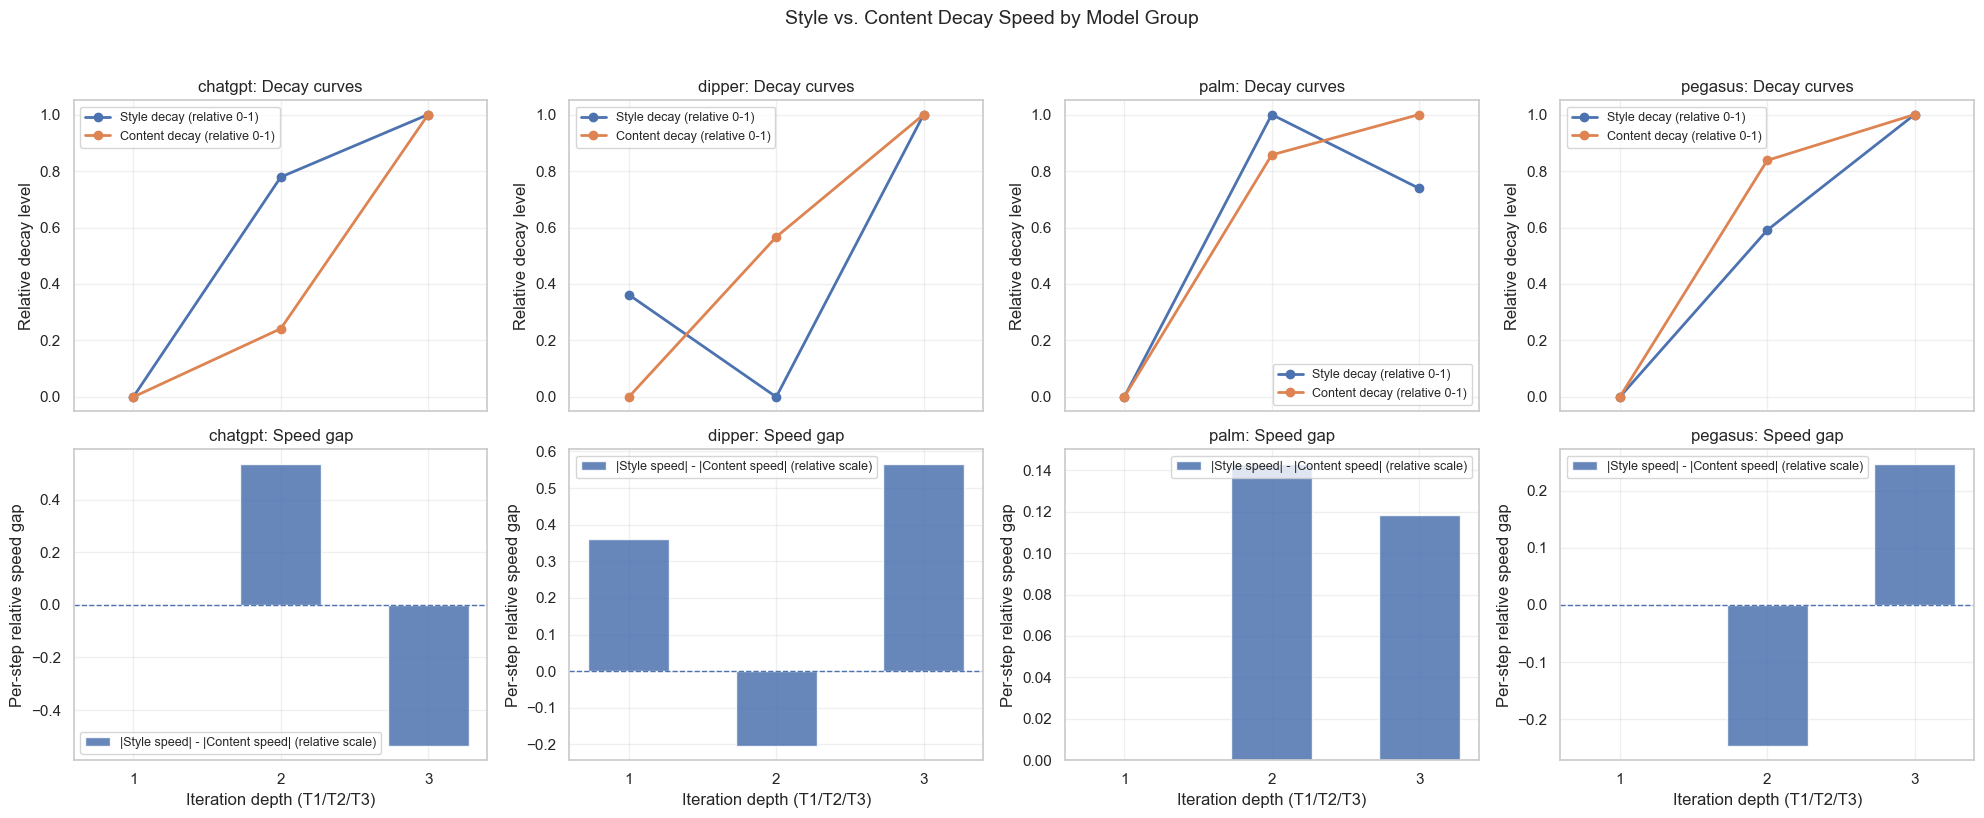

In [20]:
### Style vs. Content Decay Speed By Model
### Relative-comparable style/content decay on a shared [0, 1] scale

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# helper: min-max to [0, 1]
# -----------------------------
def minmax01(s):
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if abs(mx - mn) < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)


# Style signal (lexical drift) columns from planks_table
style_abs_cols = [
    "delta_tok_len_abs_mean",
    "delta_ttr_abs_mean",
    "delta_avg_word_len_abs_mean",
    "delta_punct_ratio_abs_mean",
]

model_groups = sorted(eval_pairs["model_group"].dropna().unique())
if len(model_groups) == 0:
    raise ValueError("No model_group values found in eval_pairs.")

# -----------------------------
# 1. Scale each style feature separately across all rows
# -----------------------------
style_scaled = planks_table.copy()
scaled_cols = []

for col in style_abs_cols:
    col_std = float(style_scaled[col].std(ddof=0))
    if col_std < 1e-12:
        col_std = 1.0
    scaled_col = col + "_scaled"
    style_scaled[scaled_col] = style_scaled[col] / col_std
    scaled_cols.append(scaled_col)

print("Per-feature style scaling used:")
for col in style_abs_cols:
    print(f"  {col}: std={style_scaled[col].std(ddof=0):.6f}")

# -----------------------------
# 2. Build per-model decay/speed tables
# -----------------------------
model_decay_tables = {}

for mg in model_groups:
    # Content decay: 1 - SBERT cosine
    content_by_depth = (
        eval_pairs.loc[eval_pairs["model_group"] == mg]
        .groupby("depth", as_index=False)["sbert_cosine"]
        .mean()
        .sort_values("depth")
        .rename(columns={"sbert_cosine": "content_retention"})
    )
    content_by_depth["content_decay"] = 1 - content_by_depth["content_retention"]

    # Style decay: mean of per-feature normalized lexical drift
    style_by_depth = (
        style_scaled.loc[style_scaled["model_group"] == mg]
        .groupby("depth", as_index=False)[scaled_cols]
        .mean()
        .sort_values("depth")
    )
    style_by_depth["style_decay"] = style_by_depth[scaled_cols].mean(axis=1)

    # optional raw mean drift for inspection
    raw_mean_by_depth = (
        planks_table.loc[planks_table["model_group"] == mg]
        .groupby("depth", as_index=False)[style_abs_cols]
        .mean()
        .sort_values("depth")
    )
    raw_mean_by_depth["style_drift_raw_mean"] = raw_mean_by_depth[style_abs_cols].mean(
        axis=1
    )

    style_by_depth = pd.merge(
        style_by_depth,
        raw_mean_by_depth[["depth", "style_drift_raw_mean"]],
        on="depth",
        how="left",
    )

    decay_df_mg = pd.merge(
        content_by_depth[["depth", "content_decay"]],
        style_by_depth[["depth", "style_decay", "style_drift_raw_mean"]],
        on="depth",
        how="inner",
    ).sort_values("depth")

    # -----------------------------
    # 3. Put style and content on the same [0, 1] relative scale
    # -----------------------------
    decay_df_mg["style_decay_rel"] = minmax01(decay_df_mg["style_decay"])
    decay_df_mg["content_decay_rel"] = minmax01(decay_df_mg["content_decay"])

    # -----------------------------
    # 4. Per-step relative speed
    #    T1 speed is relative to T0 baseline = 0
    # -----------------------------
    decay_df_mg["content_speed_rel"] = decay_df_mg["content_decay_rel"].diff()
    decay_df_mg["style_speed_rel"] = decay_df_mg["style_decay_rel"].diff()

    if len(decay_df_mg) > 0:
        first_idx = decay_df_mg.index[0]
        decay_df_mg.loc[first_idx, "content_speed_rel"] = decay_df_mg.loc[
            first_idx, "content_decay_rel"
        ]
        decay_df_mg.loc[first_idx, "style_speed_rel"] = decay_df_mg.loc[
            first_idx, "style_decay_rel"
        ]

    decay_df_mg["content_speed_rel"] = decay_df_mg["content_speed_rel"].abs()
    decay_df_mg["style_speed_rel"] = decay_df_mg["style_speed_rel"].abs()
    decay_df_mg["speed_diff_rel_style_minus_content"] = (
        decay_df_mg["style_speed_rel"] - decay_df_mg["content_speed_rel"]
    )

    model_decay_tables[mg] = decay_df_mg

# -----------------------------
# 5. Display combined table
# -----------------------------
combined_decay = pd.concat(
    [df.assign(model_group=mg) for mg, df in model_decay_tables.items()],
    axis=0,
    ignore_index=True,
)[
    [
        "model_group",
        "depth",
        "style_decay",
        "content_decay",
        "style_decay_rel",
        "content_decay_rel",
        "style_speed_rel",
        "content_speed_rel",
        "speed_diff_rel_style_minus_content",
    ]
]

print("\nPer-model decay and speed table:")
display(combined_decay.sort_values(["model_group", "depth"]))

# -----------------------------
# 6. Plot small multiples
# -----------------------------
n = len(model_groups)
fig, axes = plt.subplots(2, n, figsize=(5 * n, 8), sharex="col")
if n == 1:
    axes = np.array(axes).reshape(2, 1)

for i, mg in enumerate(model_groups):
    d = model_decay_tables[mg]

    # Top: relative cumulative decay
    axes[0, i].plot(
        d["depth"],
        d["style_decay_rel"],
        marker="o",
        linewidth=2,
        label="Style decay (relative 0-1)",
    )
    axes[0, i].plot(
        d["depth"],
        d["content_decay_rel"],
        marker="o",
        linewidth=2,
        label="Content decay (relative 0-1)",
    )
    axes[0, i].set_title(f"{mg}: Decay curves")
    axes[0, i].set_ylabel("Relative decay level")
    axes[0, i].set_xticks(sorted(d["depth"].unique()))
    axes[0, i].grid(alpha=0.3)
    axes[0, i].legend(fontsize=9)

    # Bottom: relative speed difference per step
    axes[1, i].axhline(0, linestyle="--", linewidth=1)
    axes[1, i].bar(
        d["depth"],
        d["speed_diff_rel_style_minus_content"],
        width=0.55,
        alpha=0.85,
        label="|Style speed| - |Content speed| (relative scale)",
    )
    axes[1, i].set_title(f"{mg}: Speed gap")
    axes[1, i].set_xlabel("Iteration depth (T1/T2/T3)")
    axes[1, i].set_ylabel("Per-step relative speed gap")
    axes[1, i].set_xticks(sorted(d["depth"].unique()))
    axes[1, i].grid(alpha=0.3)
    axes[1, i].legend(fontsize=9)

fig.suptitle("Style vs. Content Decay Speed by Model Group", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Per-feature style scaling used:
  delta_tok_len_abs_mean: std=28.693849
  delta_ttr_abs_mean: std=0.032033
  delta_avg_word_len_abs_mean: std=0.151762
  delta_punct_ratio_abs_mean: std=0.001220


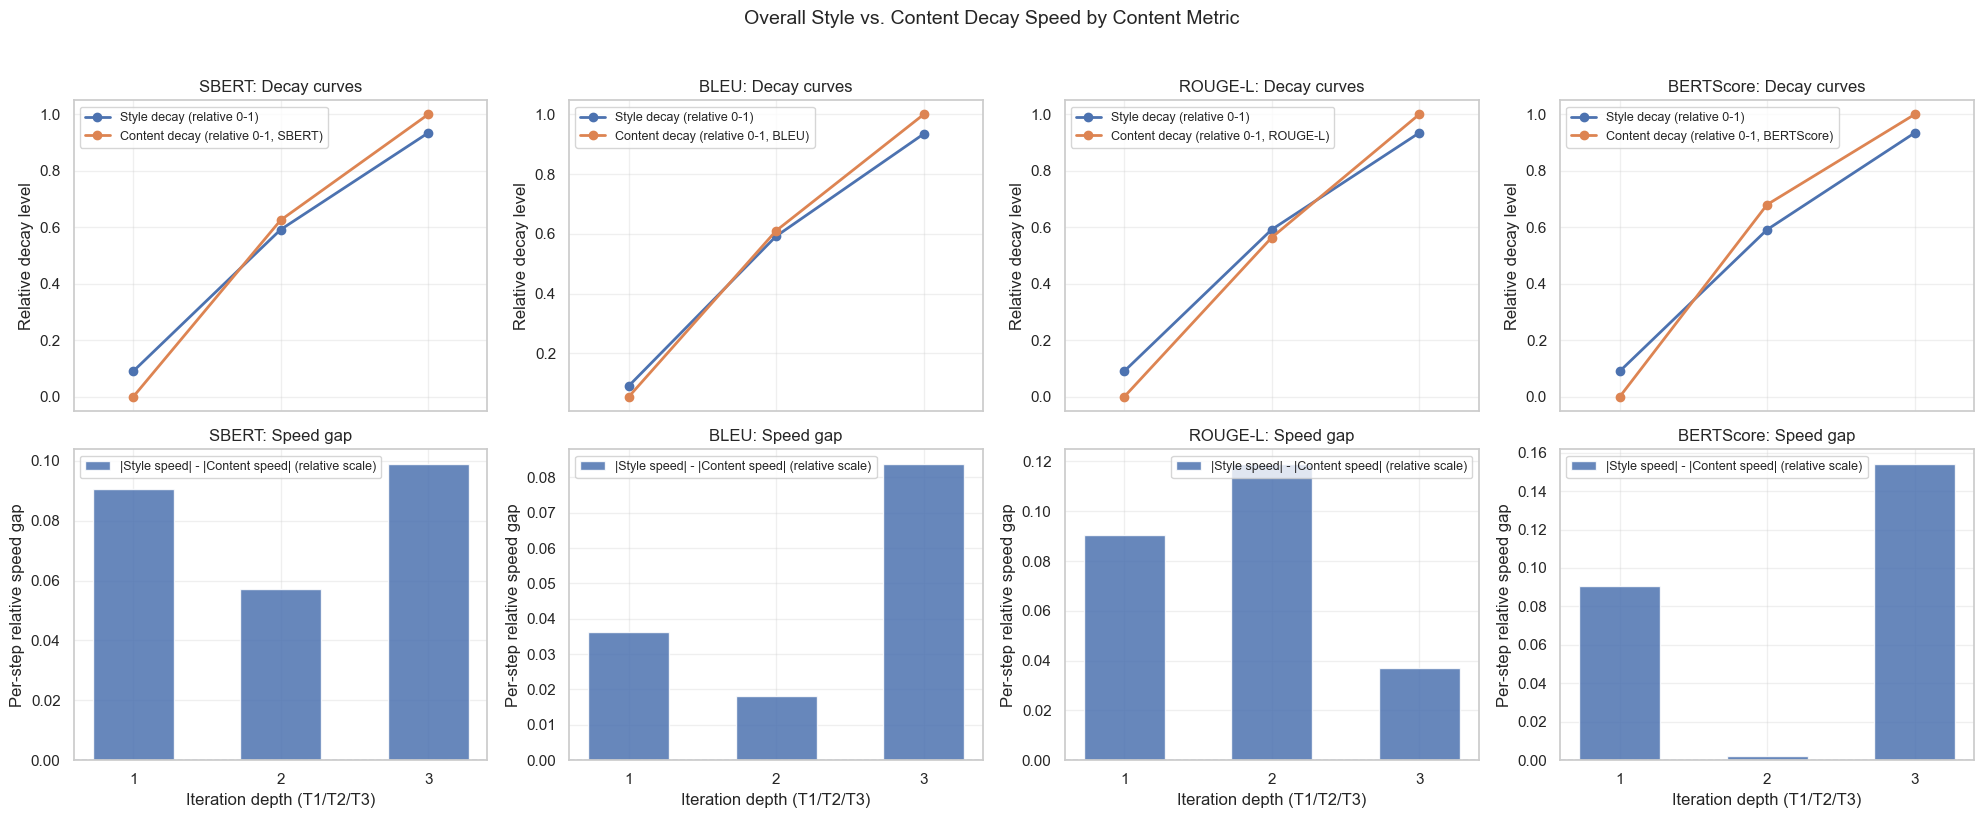

By-model, by-metric relative speed-gap table:


,depth,speed_diff_rel_style_minus_content,style_drift_raw_mean,style_decay_rel,content_decay_rel,model_group,metric
0,1,0.000000,11.216506,0.000000,0.000000,chatgpt,BERTScore
1,2,0.119778,22.425787,0.778556,0.658778,chatgpt,BERTScore
2,3,-0.119778,22.233932,1.000000,1.000000,chatgpt,BERTScore
3,1,0.362049,33.132234,0.362049,0.000000,dipper,BERTScore
4,2,-0.165595,29.937218,0.000000,0.527643,dipper,BERTScore
5,3,0.527643,27.733539,1.000000,1.000000,dipper,BERTScore
6,1,0.000000,20.068483,0.000000,0.000000,palm,BERTScore
7,2,0.270563,19.876862,1.000000,0.729437,palm,BERTScore
8,3,-0.009031,19.781564,0.738468,1.000000,palm,BERTScore
9,1,0.000000,36.582056,0.000000,0.000000,pegasus,BERTScore


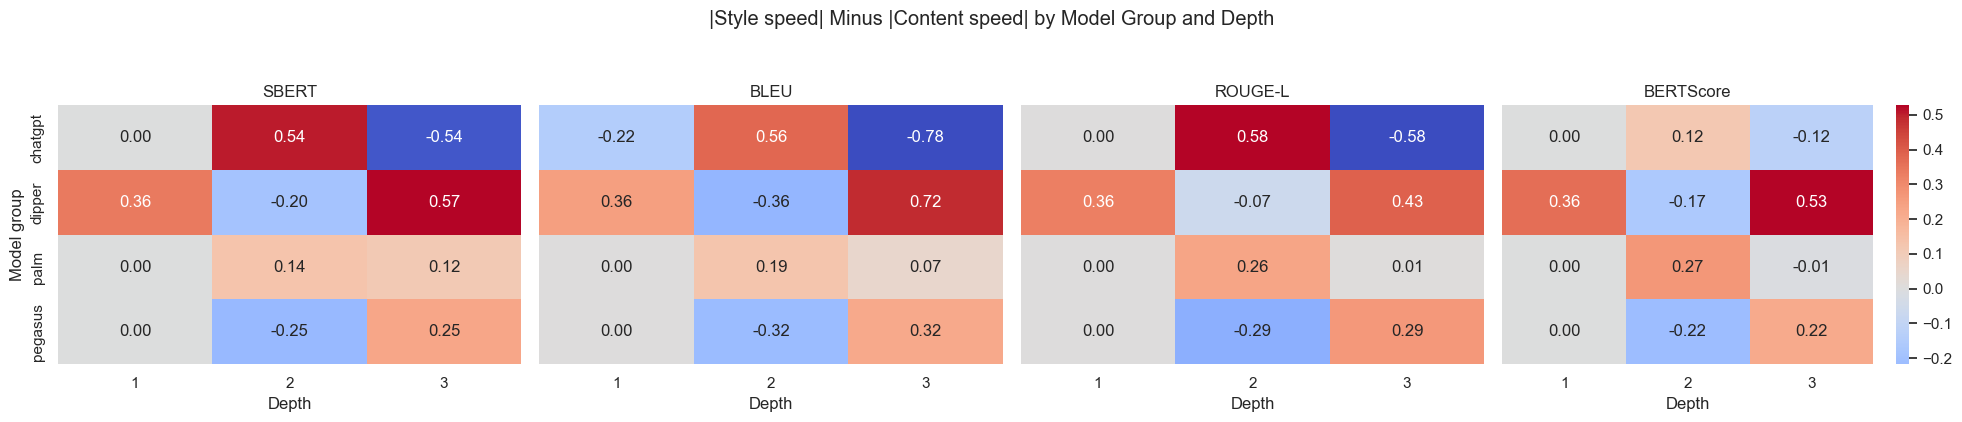

In [21]:
### Multi-Metric Style vs. Content Decay Speed Comparison
### Relative-comparable style/content decay on a shared [0, 1] scale

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# -----------------------------
# helper: min-max to [0, 1]
# -----------------------------
def minmax01(s):
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if abs(mx - mn) < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)


metric_map = {
    "sbert_cosine": "SBERT",
    "bleu": "BLEU",
    "rouge_l": "ROUGE-L",
    "bert_score": "BERTScore",
}

missing_metrics = [m for m in metric_map if m not in eval_pairs.columns]
if missing_metrics:
    raise ValueError(f"Missing metric columns in eval_pairs: {missing_metrics}")

style_abs_cols = [
    "delta_tok_len_abs_mean",
    "delta_ttr_abs_mean",
    "delta_avg_word_len_abs_mean",
    "delta_punct_ratio_abs_mean",
]
missing_style_cols = [c for c in style_abs_cols if c not in planks_table.columns]
if missing_style_cols:
    raise ValueError(f"Missing style columns in planks_table: {missing_style_cols}")

# -----------------------------
# 1. Scale each style feature separately
# -----------------------------
style_scaled = planks_table.copy()
scaled_cols = []

for col in style_abs_cols:
    col_std = float(style_scaled[col].std(ddof=0))
    if col_std < 1e-12:
        col_std = 1.0
    scaled_col = col + "_scaled"
    style_scaled[scaled_col] = style_scaled[col] / col_std
    scaled_cols.append(scaled_col)

print("Per-feature style scaling used:")
for col in style_abs_cols:
    print(f"  {col}: std={style_scaled[col].std(ddof=0):.6f}")


def build_decay_table(
    eval_df_sub, planks_df_sub_scaled, planks_df_sub_raw, content_col
):
    # content decay
    content_by_depth = (
        eval_df_sub.groupby("depth", as_index=False)[content_col]
        .mean()
        .sort_values("depth")
        .rename(columns={content_col: "content_retention"})
    )
    content_by_depth["content_decay"] = 1 - content_by_depth["content_retention"]

    # style decay from per-feature normalized drift
    style_by_depth = (
        planks_df_sub_scaled.groupby("depth", as_index=False)[scaled_cols]
        .mean()
        .sort_values("depth")
    )
    style_by_depth["style_decay"] = style_by_depth[scaled_cols].mean(axis=1)

    # optional raw mean drift for inspection
    raw_style_by_depth = (
        planks_df_sub_raw.groupby("depth", as_index=False)[style_abs_cols]
        .mean()
        .sort_values("depth")
    )
    raw_style_by_depth["style_drift_raw_mean"] = raw_style_by_depth[
        style_abs_cols
    ].mean(axis=1)

    out = pd.merge(
        content_by_depth[["depth", "content_decay"]],
        style_by_depth[["depth", "style_decay"]],
        on="depth",
        how="inner",
    ).sort_values("depth")

    out = pd.merge(
        out,
        raw_style_by_depth[["depth", "style_drift_raw_mean"]],
        on="depth",
        how="left",
    )

    # -----------------------------
    # put style and content on same [0,1] relative scale
    # -----------------------------
    out["style_decay_rel"] = minmax01(out["style_decay"])
    out["content_decay_rel"] = minmax01(out["content_decay"])

    # per-step relative speed
    out["content_speed_rel"] = out["content_decay_rel"].diff()
    out["style_speed_rel"] = out["style_decay_rel"].diff()

    if len(out) > 0:
        first_idx = out.index[0]
        out.loc[first_idx, "content_speed_rel"] = out.loc[
            first_idx, "content_decay_rel"
        ]
        out.loc[first_idx, "style_speed_rel"] = out.loc[first_idx, "style_decay_rel"]

    out["content_speed_rel"] = out["content_speed_rel"].abs()
    out["style_speed_rel"] = out["style_speed_rel"].abs()
    out["speed_diff_rel_style_minus_content"] = (
        out["style_speed_rel"] - out["content_speed_rel"]
    )
    return out


# -----------------------------
# 2. Build per-model / per-metric tables
# -----------------------------
model_groups = sorted(eval_pairs["model_group"].dropna().unique())
rows = []

for mg in model_groups:
    eval_mg = eval_pairs[eval_pairs["model_group"] == mg]
    plank_mg_scaled = style_scaled[style_scaled["model_group"] == mg]
    plank_mg_raw = planks_table[planks_table["model_group"] == mg]

    for metric_col, metric_name in metric_map.items():
        d = build_decay_table(eval_mg, plank_mg_scaled, plank_mg_raw, metric_col)
        d["model_group"] = mg
        d["metric"] = metric_name
        rows.append(d)

by_model_metric_full = pd.concat(rows, ignore_index=True)

# -----------------------------
# 3. Overall tables aggregated from per-model tables
# -----------------------------
overall_tables = {
    metric_name: (
        by_model_metric_full[by_model_metric_full["metric"] == metric_name]
        .groupby("depth", as_index=False)[
            [
                "style_decay_rel",
                "content_decay_rel",
                "style_speed_rel",
                "content_speed_rel",
                "speed_diff_rel_style_minus_content",
            ]
        ]
        .mean()
        .sort_values("depth")
    )
    for metric_name in metric_map.values()
}

# -----------------------------
# 4. Overall comparison across metrics
# -----------------------------
fig, axes = plt.subplots(
    2, len(overall_tables), figsize=(5 * len(overall_tables), 8), sharex="col"
)
if len(overall_tables) == 1:
    axes = np.array(axes).reshape(2, 1)

for i, (metric_name, df_metric) in enumerate(overall_tables.items()):
    axes[0, i].plot(
        df_metric["depth"],
        df_metric["style_decay_rel"],
        marker="o",
        linewidth=2,
        label="Style decay (relative 0-1)",
    )
    axes[0, i].plot(
        df_metric["depth"],
        df_metric["content_decay_rel"],
        marker="o",
        linewidth=2,
        label=f"Content decay (relative 0-1, {metric_name})",
    )
    axes[0, i].set_title(f"{metric_name}: Decay curves")
    axes[0, i].set_ylabel("Relative decay level")
    axes[0, i].set_xticks(sorted(df_metric["depth"].unique()))
    axes[0, i].grid(alpha=0.3)
    axes[0, i].legend(fontsize=9)

    axes[1, i].axhline(0, linestyle="--", linewidth=1)
    axes[1, i].bar(
        df_metric["depth"],
        df_metric["speed_diff_rel_style_minus_content"],
        width=0.55,
        alpha=0.85,
        label="|Style speed| - |Content speed| (relative scale)",
    )
    axes[1, i].set_title(f"{metric_name}: Speed gap")
    axes[1, i].set_xlabel("Iteration depth (T1/T2/T3)")
    axes[1, i].set_ylabel("Per-step relative speed gap")
    axes[1, i].set_xticks(sorted(df_metric["depth"].unique()))
    axes[1, i].grid(alpha=0.3)
    axes[1, i].legend(fontsize=9)

fig.suptitle(
    "Overall Style vs. Content Decay Speed by Content Metric", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

# -----------------------------
# 5. By-model / by-metric inspection table
# -----------------------------
by_model_metric = by_model_metric_full[
    [
        "depth",
        "speed_diff_rel_style_minus_content",
        "style_drift_raw_mean",
        "style_decay_rel",
        "content_decay_rel",
        "model_group",
        "metric",
    ]
]

print("By-model, by-metric relative speed-gap table:")
display(
    by_model_metric.sort_values(["metric", "model_group", "depth"]).reset_index(
        drop=True
    )
)

# -----------------------------
# 6. Heatmaps
# -----------------------------
fig, axes = plt.subplots(
    1, len(metric_map), figsize=(5 * len(metric_map), 4), sharey=True
)
if len(metric_map) == 1:
    axes = [axes]

for i, metric_name in enumerate(metric_map.values()):
    sub = by_model_metric[by_model_metric["metric"] == metric_name].copy()
    heat = (
        sub.pivot(
            index="model_group",
            columns="depth",
            values="speed_diff_rel_style_minus_content",
        )
        .sort_index()
        .sort_index(axis=1)
    )
    sns.heatmap(
        heat,
        ax=axes[i],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        cbar=(i == len(metric_map) - 1),
    )
    axes[i].set_title(metric_name)
    axes[i].set_xlabel("Depth")
    axes[i].set_ylabel("Model group" if i == 0 else "")

plt.suptitle("|Style speed| Minus |Content speed| by Model Group and Depth", y=1.05)
plt.tight_layout()
plt.show()

## Part 2: The Point of No Return

#### POS-tag Frequencies: T0 to T3

In this step, we first compute the POS distribution for each individual text, and then average the results across all texts within the same stage (T0, T1, T2, and T3).

As shown below, `pos_summary` reports the average proportion of tokens assigned to each POS category at each stage, such as nouns, verbs, adjectives, and pronouns.

As a sanity check, the values in each row sum to 1, which helps verify that the POS distributions were computed correctly.

In [22]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter

for pkg in [
    "punkt",
    "punkt_tab",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "universal_tagset",
]:
    try:
        nltk.download(pkg)
    except:
        pass

POS_TAGS = [
    "NOUN",
    "VERB",
    "ADJ",
    "ADV",
    "PRON",
    "DET",
    "ADP",
    "NUM",
    "CONJ",
    "PRT",
    "X",
    ".",
]


def pos_freqs(text):
    text = str(text) if text is not None else ""
    tokens = word_tokenize(text)
    if not tokens:
        return {t: 0.0 for t in POS_TAGS}
    tags = nltk.pos_tag(tokens, tagset="universal")
    c = Counter(tag for _, tag in tags)
    total = sum(c.values()) or 1
    return {t: c.get(t, 0) / total for t in POS_TAGS}


print("Computing POS distributions for T0...")
t0_pos = eval_pairs["human_ref"].apply(pos_freqs)
t0_df = pd.json_normalize(t0_pos.tolist()).add_prefix("T0_")
t0_df.index = eval_pairs.index

print("Computing POS distributions for AI texts...")
cand_pos = eval_pairs["text_cleaned"].apply(pos_freqs)
cand_df = pd.json_normalize(cand_pos.tolist()).add_prefix("cand_")
cand_df.index = eval_pairs.index

eval_pairs[t0_df.columns] = t0_df
eval_pairs[cand_df.columns] = cand_df

for tag in POS_TAGS:
    eval_pairs[f"delta_pos_{tag}"] = eval_pairs[f"cand_{tag}"] - eval_pairs[f"T0_{tag}"]

summary_rows = []

# T0 summary
t0_means = eval_pairs[[f"T0_{tag}" for tag in POS_TAGS]].mean()
t0_row = {"stage": "T0"}
for tag in POS_TAGS:
    t0_row[tag] = t0_means[f"T0_{tag}"]
summary_rows.append(t0_row)

# T1/T2/T3 summary
for d in sorted(eval_pairs["depth"].dropna().unique()):
    sub = eval_pairs[eval_pairs["depth"] == d]
    cand_means = sub[[f"cand_{tag}" for tag in POS_TAGS]].mean()
    row = {"stage": f"T{int(d)}"}
    for tag in POS_TAGS:
        row[tag] = cand_means[f"cand_{tag}"]
    summary_rows.append(row)

pos_summary = pd.DataFrame(summary_rows)
display(pos_summary)

[nltk_data] Downloading package punkt to /home/mack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/mack/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/mack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/mack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /home/mack/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


Computing POS distributions for T0...
Computing POS distributions for AI texts...


,stage,NOUN,VERB,ADJ,ADV,PRON,DET,ADP,NUM,CONJ,PRT,X,.
0,T0,0.219003,0.182636,0.092075,0.077992,0.061425,0.092803,0.084012,0.011839,0.037227,0.026110,0.000966,0.113913
1,T1,0.214672,0.185127,0.095157,0.063565,0.067175,0.101213,0.082957,0.007633,0.037601,0.029182,0.000525,0.115193
2,T2,0.213332,0.190010,0.094306,0.058496,0.069354,0.103649,0.083648,0.007258,0.034416,0.029433,0.000474,0.115624
3,T3,0.213483,0.190277,0.096832,0.057658,0.069043,0.103638,0.083044,0.006789,0.033488,0.028755,0.000425,0.116568


#### Dependency Tree Depth: T0 to T3

In this step, we compute dependency tree depth for each individual text by parsing its sentences with a dependency parser and measuring, for each sentence, the maximum path length from the root node to any dependent token. We then average the sentence-level depths within each text, and finally average these per-text values across all samples in the same stage (T0, T1, T2, and T3).

In general, a larger dependency tree depth indicates a deeper syntactic structure, meaning the sentence contains more levels of dependency relations and tends to be more nested or structurally complex.

As shown below:

- **T0:** 3.98
- **T1:** 4.37
- **T2:** 4.28
- **T3:** 4.25

The average dependency tree depth increases from T0 to T1, then decreases slightly in T2 and T3. Overall, AI paraphrases remain syntactically deeper than the human originals.

In [23]:
import pandas as pd
import spacy
import numpy as np

nlp = spacy.load("en_core_web_sm")


def token_depth(token):
    depth = 0
    cur = token
    while cur.head != cur:
        depth += 1
        cur = cur.head
    return depth


def sentence_tree_depth(sent):
    if len(sent) == 0:
        return 0
    return max(token_depth(token) for token in sent)


def text_avg_dep_depth(text):
    text = str(text) if text is not None else ""
    doc = nlp(text)
    sent_depths = [sentence_tree_depth(sent) for sent in doc.sents if len(sent) > 0]
    if not sent_depths:
        return 0.0
    return float(np.mean(sent_depths))


print("Computing dependency tree depths for T0...")
eval_pairs["T0_dep_depth"] = eval_pairs["human_ref"].apply(text_avg_dep_depth)

print("Computing dependency tree depths for AI texts...")
eval_pairs["cand_dep_depth"] = eval_pairs["text_cleaned"].apply(text_avg_dep_depth)

eval_pairs["delta_dep_depth"] = (
    eval_pairs["cand_dep_depth"] - eval_pairs["T0_dep_depth"]
)

summary_rows = []

# T0
summary_rows.append({"stage": "T0", "avg_dep_depth": eval_pairs["T0_dep_depth"].mean()})

# T1/T2/T3
for d in sorted(eval_pairs["depth"].dropna().unique()):
    sub = eval_pairs[eval_pairs["depth"] == d]
    summary_rows.append(
        {"stage": f"T{int(d)}", "avg_dep_depth": sub["cand_dep_depth"].mean()}
    )

dep_summary = pd.DataFrame(summary_rows)
display(dep_summary)

Computing dependency tree depths for T0...
Computing dependency tree depths for AI texts...


,stage,avg_dep_depth
0,T0,3.982019
1,T1,4.372885
2,T2,4.277184
3,T3,4.249680


> **Note**

The results show mild linguistic drift rather than severe linguistic decay.

1. **POS-tag frequencies** change gradually across paraphrase stages, but the shifts are relatively small, suggesting that the overall grammatical composition remains fairly stable.

2. **Dependency tree depth** rises above the human baseline and remains elevated through T3, indicating that repeated paraphrasing introduces slightly deeper syntactic structures rather than progressively simplifying them.

#### PCA visualization of the Identity Trajectory

In this step, we reuse the SBERT text embeddings computed in Code Block 22, specifically the `text2emb` mapping from each text to its embedding vector. We then apply PCA to reduce these high-dimensional embeddings to two dimensions, so that texts from T0, T1, T2, and T3 can be visualized in a shared 2D space.

The resulting PCA plot shows the relative positions of texts across stages in the embedding space. This is useful for understanding whether repeated paraphrasing preserves a similar semantic identity, gradually shifts the text away from the human baseline, or compresses later-stage outputs into a narrower machine-like region.

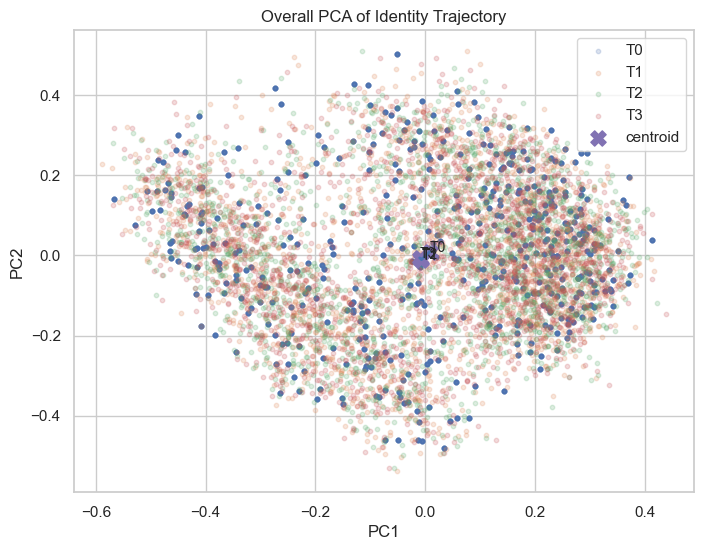

,stage,n_points,mean_distance_to_centroid,std_distance_to_centroid,pc1_variance,pc2_variance
0,T0,5892,0.280231,0.108756,0.054819,0.035539
1,T1,1964,0.279125,0.106258,0.053398,0.035803
2,T2,1964,0.275806,0.105550,0.053656,0.033554
3,T3,1964,0.273806,0.104822,0.052669,0.033288


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

rows = []

# T0
for _, row in eval_pairs.iterrows():
    txt = str(row["human_ref"])
    if txt in text2emb:
        rows.append({"stage": "T0", "text": txt, "embedding": text2emb[txt]})

# T1/T2/T3
for _, row in eval_pairs.iterrows():
    txt = str(row["text_cleaned"])
    stage = f"T{int(row['depth'])}"
    if txt in text2emb:
        rows.append({"stage": stage, "text": txt, "embedding": text2emb[txt]})

traj_df = pd.DataFrame(rows)

X = np.vstack(traj_df["embedding"].values)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

traj_df["pc1"] = coords[:, 0]
traj_df["pc2"] = coords[:, 1]

stage_order = ["T0", "T1", "T2", "T3"]

plt.figure(figsize=(8, 6))
for stage in stage_order:
    sub = traj_df[traj_df["stage"] == stage]
    plt.scatter(sub["pc1"], sub["pc2"], alpha=0.2, s=10, label=stage)

centroids = (
    traj_df.groupby("stage")[["pc1", "pc2"]].mean().reindex(stage_order).reset_index()
)

plt.scatter(centroids["pc1"], centroids["pc2"], s=120, marker="X", label="centroid")

plt.plot(centroids["pc1"], centroids["pc2"], linewidth=2)

for _, r in centroids.iterrows():
    plt.text(r["pc1"], r["pc2"], r["stage"], fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Overall PCA of Identity Trajectory")
plt.legend()
plt.show()

dispersion_rows = []

for stage in stage_order:
    sub = traj_df[traj_df["stage"] == stage][["pc1", "pc2"]].values
    centroid = sub.mean(axis=0)
    dists = np.linalg.norm(sub - centroid, axis=1)

    dispersion_rows.append(
        {
            "stage": stage,
            "n_points": len(sub),
            "mean_distance_to_centroid": dists.mean(),
            "std_distance_to_centroid": dists.std(),
            "pc1_variance": sub[:, 0].var(),
            "pc2_variance": sub[:, 1].var(),
        }
    )

dispersion_df = pd.DataFrame(dispersion_rows)
display(dispersion_df)

#### Findings from the PCA Visualization

We analyze the PCA plot to examine whether repeated paraphrasing creates a clear identity trajectory from human-written text toward a more compressed machine-like region.

1. **Strong overlap across stages.**
   The PCA plot shows substantial overlap among T0, T1, T2, and T3, meaning that human texts and AI paraphrases do not form clearly separated regions in the embedding space.

2. **Weak centroid movement.**
   The stage centroids are all clustered near the origin, indicating that the overall movement from T0 to T3 is small and that the identity trajectory is weak.

3. **Only mild compression.**
   The dispersion statistics show only a slight decrease in mean distance to centroid from T0 to T3, suggesting at most mild compression rather than strong convergence toward a machine region.

Overall, the results suggest a small amount of drift across paraphrase stages, suggesting that we may have a good result using classification models like SVM to distinguish between authors on all iterations.

### The "Point of No Return" - Authorship Attribution Testing

**Goal:** Determine at which iteration (T1, T2, or T3) the original author's "stylistic DNA" becomes undetectable.

**Approach:** We'll train an SVM classifier to distinguish between different original authors (Human vs. different AI sources) using stylistic features. Then we'll test the classifier on paraphrased texts at each depth to see when authorship attribution accuracy drops significantly.

**Features used:**
- n-gram TF-IDF
- Type Token Ratio
- Word Length
- Punctuation Ratio

Additionally, an **Ablation Study** is attached below.

In [25]:
# Task 3: Prepare data for authorship attribution (char n-gram TF-IDF + lexical features)
import pandas as pd
import numpy as np
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Get T0 texts with source labels
df_t0 = df_eval[df_eval["depth"] == 0][["key", "source", "text_cleaned"]].copy()
df_t0 = df_t0.drop_duplicates(subset=["key"])

print(f"T0 samples (raw): {len(df_t0)}")
print(f"Source distribution:\n{df_t0['source'].value_counts()}")

# Task 3 model features (TF-IDF + lexical only)
author_t0_style_cols = [
    "ref_tok_len",
    "ref_ttr",
    "ref_avg_word_len",
    "ref_punct_ratio",
]

author_cand_style_cols = [
    "cand_tok_len",
    "cand_ttr",
    "cand_avg_word_len",
    "cand_punct_ratio",
]

# Keep these available in df_t0 so Cell 34 (ablation) can remain unchanged.
author_t0_aux_cols_for_ablation = [f"T0_{tag}" for tag in POS_TAGS] + ["T0_dep_depth"]

# Required columns for current Task 3 model + Cell 34 compatibility
required_cols = set(
    author_t0_style_cols
    + author_cand_style_cols
    + author_t0_aux_cols_for_ablation
    + [f"cand_{tag}" for tag in POS_TAGS]
    + ["cand_dep_depth"]
)
missing_cols = sorted(c for c in required_cols if c not in eval_pairs.columns)
if missing_cols:
    raise ValueError(
        "Missing required columns in eval_pairs. "
        "Please run Cells 16, 23, and 25 first.\n"
        f"Missing: {missing_cols}"
    )

# Attach one row of T0 features per key; include aux columns to preserve Cell 34 behavior
merge_t0_cols = author_t0_style_cols + author_t0_aux_cols_for_ablation
t0_style = eval_pairs[["key"] + merge_t0_cols].drop_duplicates(subset=["key"])
df_t0 = df_t0.merge(t0_style, on="key", how="inner")

# Ensure numeric and fill missing values safely
df_t0[merge_t0_cols] = (
    df_t0[merge_t0_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
)

print(f"T0 samples after feature merge: {len(df_t0)}")

# Character n-gram TF-IDF:
#   analyzer='char_wb' — n-grams within word boundaries (captures spacing/punctuation style)
#   ngram_range=(2,4)  — bigrams to 4-grams cover most stylistic patterns
#   max_features=5000  — top features by TF-IDF weight
#   sublinear_tf=True  — log-scale TF to reduce domination by frequent chars
print("\nBuilding char n-gram TF-IDF features...")
tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 4),
    max_features=5000,
    sublinear_tf=True,
)
X_t0_text = tfidf.fit_transform(df_t0["text_cleaned"].astype(str))

# Scale lexical features then append to sparse TF-IDF matrix
author_style_scaler = StandardScaler()
X_t0_style = csr_matrix(
    author_style_scaler.fit_transform(df_t0[author_t0_style_cols].to_numpy(dtype=float))
)

X_t0 = hstack([X_t0_text, X_t0_style], format="csr")
y_t0 = df_t0["source"].astype(str).to_numpy()

print(f"Text feature matrix shape:  {X_t0_text.shape}")
print(f"Lexical feature matrix shape: {X_t0_style.shape}")
print(f"Combined matrix shape:      {X_t0.shape}")
print(
    f"Avg non-zero text features per sample: {X_t0_text.nnz / X_t0_text.shape[0]:.1f}"
)
print(f"Added lexical features: {len(author_t0_style_cols)}")

T0 samples (raw): 491
Source distribution:
source
OpenAI         78
Tsinghua       76
BigScience     72
Human          71
PaLM           65
LLAMA          65
Eleuther-AI    64
Name: count, dtype: int64
T0 samples after feature merge: 491

Building char n-gram TF-IDF features...
Text feature matrix shape:  (491, 5000)
Lexical feature matrix shape: (491, 4)
Combined matrix shape:      (491, 5004)
Avg non-zero text features per sample: 846.1
Added lexical features: 4


Training LinearSVC for authorship attribution...

=== T0 Authorship Attribution Performance ===
Accuracy:        0.5878
Random baseline: 0.1429  (1/7 classes)

Classification Report:
              precision    recall  f1-score   support

  BigScience       0.65      0.59      0.62        22
 Eleuther-AI       0.56      0.53      0.54        19
       Human       0.54      0.33      0.41        21
       LLAMA       0.57      0.40      0.47        20
      OpenAI       0.72      1.00      0.84        23
        PaLM       0.65      0.55      0.59        20
    Tsinghua       0.44      0.65      0.53        23

    accuracy                           0.59       148
   macro avg       0.59      0.58      0.57       148
weighted avg       0.59      0.59      0.58       148



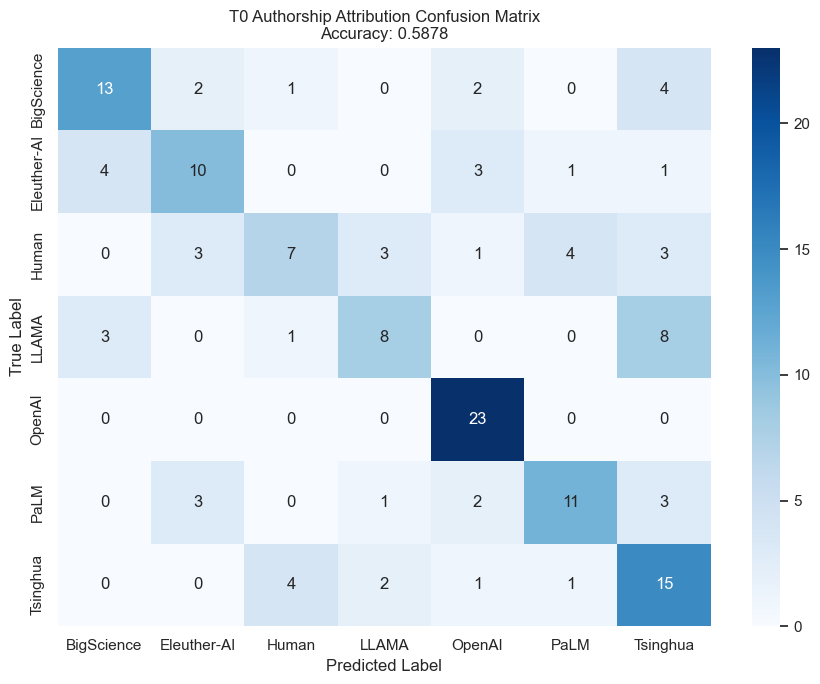

In [26]:
# Task 3: Train authorship attribution classifier on T0

y_t0 = df_t0["source"].astype(str).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_t0,
    y_t0,
    test_size=0.3,
    random_state=42,
    stratify=y_t0,
)

# LinearSVC: designed for sparse high-dimensional features, no scaling needed
print("Training LinearSVC for authorship attribution...")
svm_author = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_author.fit(X_train, y_train)

y_pred = svm_author.predict(X_test)
t0_accuracy = accuracy_score(y_test, y_pred)

print(f"\n=== T0 Authorship Attribution Performance ===")
print(f"Accuracy:        {t0_accuracy:.4f}")
print(
    f"Random baseline: {1/len(svm_author.classes_):.4f}  (1/{len(svm_author.classes_)} classes)"
)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_author.classes_,
    yticklabels=svm_author.classes_,
)
plt.title(f"T0 Authorship Attribution Confusion Matrix\nAccuracy: {t0_accuracy:.4f}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


Testing on T1 (Depth 1)
Accuracy:              0.4735
Accuracy drop from T0: 0.1143

Classification Report:
              precision    recall  f1-score   support

  BigScience       0.87      0.31      0.46       288
 Eleuther-AI       0.87      0.35      0.50       256
       Human       0.63      0.43      0.51       284
       LLAMA       0.56      0.46      0.51       260
      OpenAI       0.31      0.89      0.46       312
        PaLM       0.46      0.55      0.50       260
    Tsinghua       0.59      0.29      0.39       304

    accuracy                           0.47      1964
   macro avg       0.62      0.47      0.48      1964
weighted avg       0.61      0.47      0.47      1964



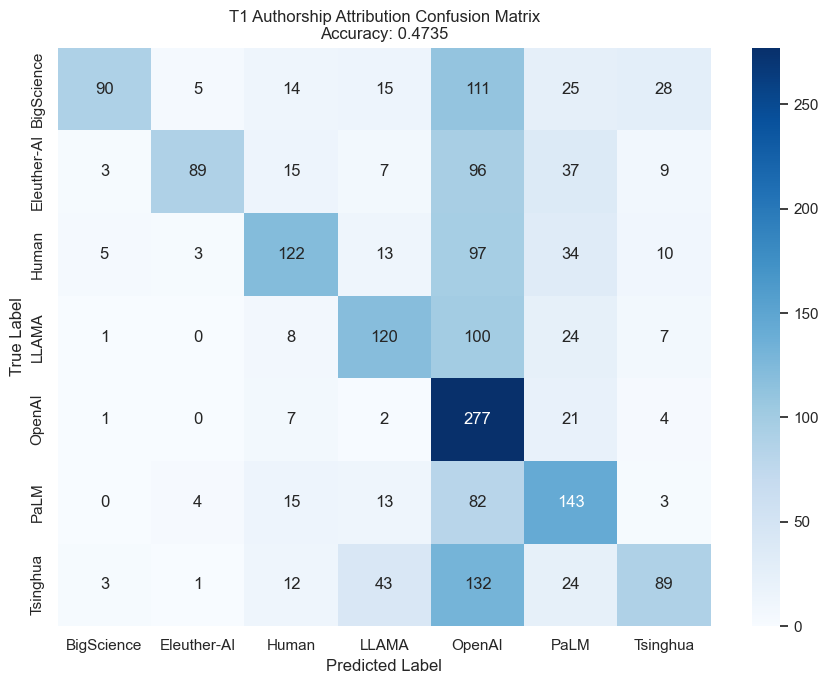


Testing on T2 (Depth 2)
Accuracy:              0.4455
Accuracy drop from T0: 0.1423

Classification Report:
              precision    recall  f1-score   support

  BigScience       0.83      0.28      0.42       288
 Eleuther-AI       0.88      0.23      0.37       256
       Human       0.54      0.44      0.49       284
       LLAMA       0.48      0.51      0.49       260
      OpenAI       0.31      0.87      0.46       312
        PaLM       0.49      0.53      0.51       260
    Tsinghua       0.48      0.22      0.30       304

    accuracy                           0.45      1964
   macro avg       0.57      0.44      0.43      1964
weighted avg       0.57      0.45      0.43      1964



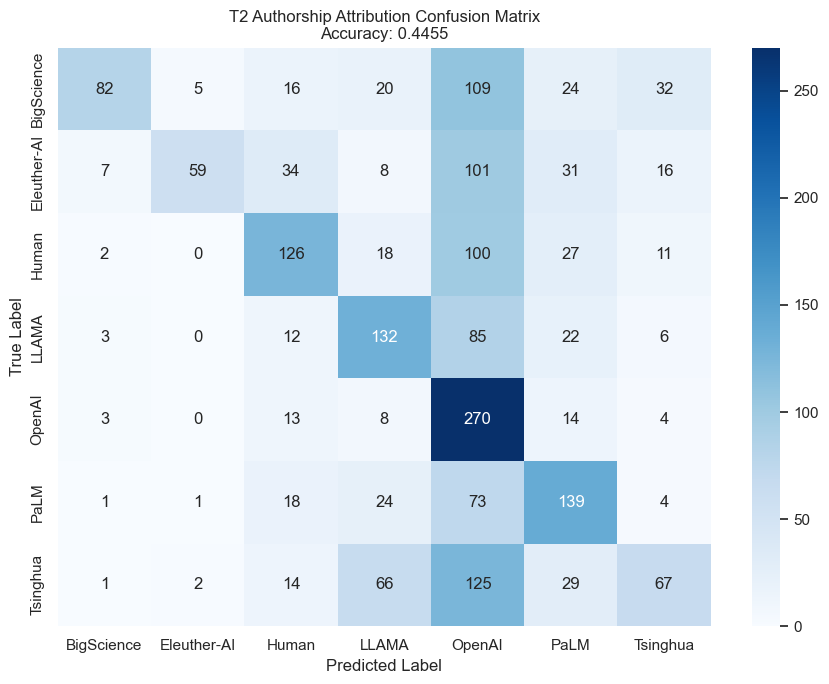


Testing on T3 (Depth 3)
Accuracy:              0.4084
Accuracy drop from T0: 0.1795

Classification Report:
              precision    recall  f1-score   support

  BigScience       0.75      0.25      0.37       288
 Eleuther-AI       0.80      0.16      0.26       256
       Human       0.47      0.41      0.44       284
       LLAMA       0.46      0.50      0.48       260
      OpenAI       0.30      0.86      0.45       312
        PaLM       0.44      0.45      0.45       260
    Tsinghua       0.45      0.19      0.26       304

    accuracy                           0.41      1964
   macro avg       0.52      0.40      0.39      1964
weighted avg       0.52      0.41      0.39      1964



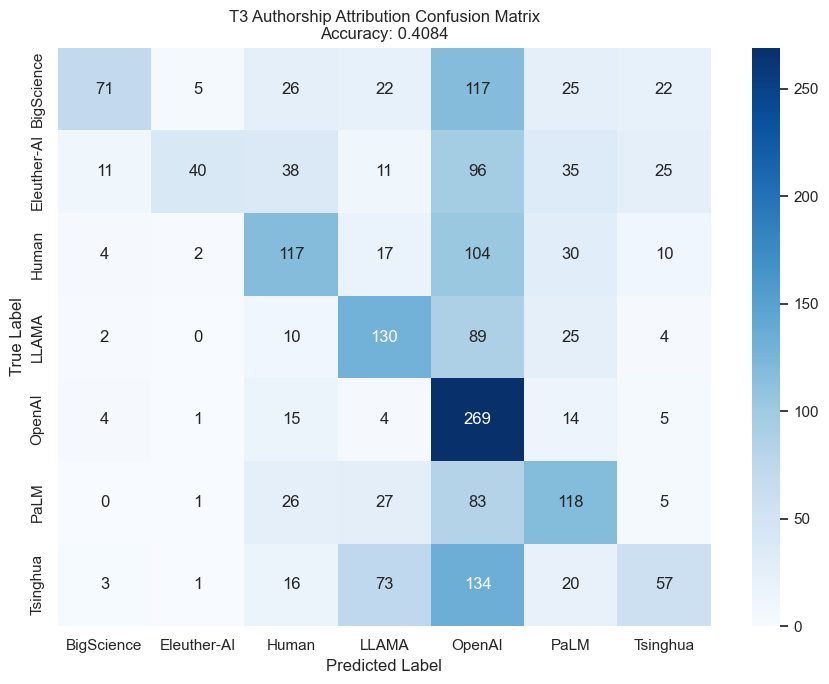


SUMMARY: Authorship Attribution Accuracy Across Depths


,depth,stage,accuracy,accuracy_drop
0,0,T0,0.587838,0.000000
1,1,T1,0.473523,0.114314
2,2,T2,0.445519,0.142318
3,3,T3,0.408350,0.179488


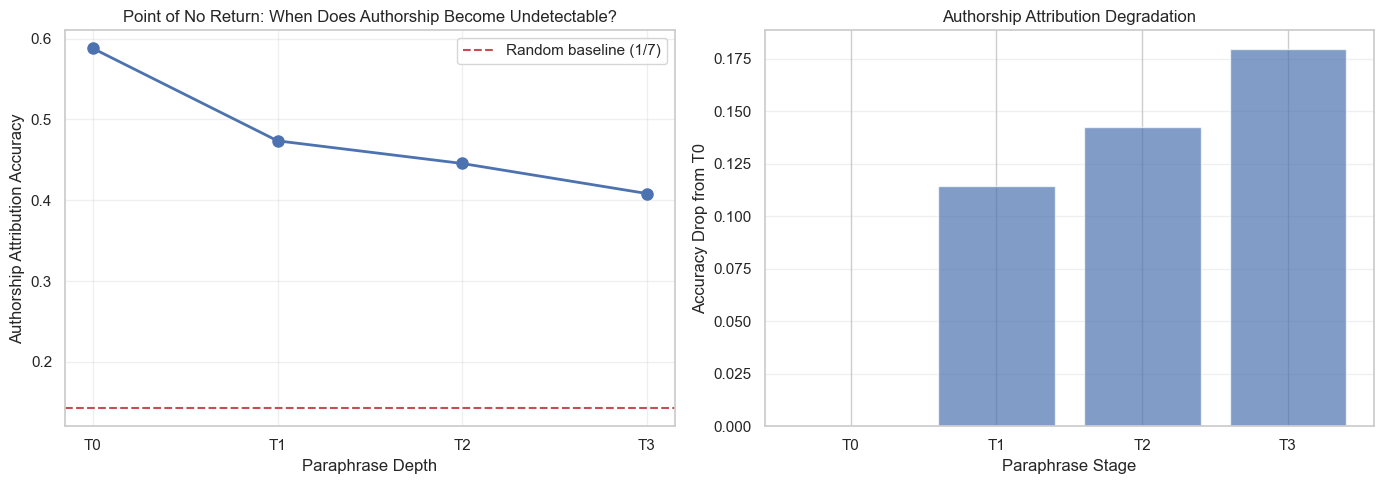

In [27]:
# Task 3: Test classifier on paraphrased texts at each depth
from scipy.sparse import hstack, csr_matrix


def prepare_features_for_depth(depth):
    df_depth = eval_pairs[eval_pairs["depth"] == depth].copy()
    df_depth = df_depth.merge(df_t0[["key", "source"]], on="key", how="left")

    # Keep rows with labels and expected stylometric columns
    df_depth = df_depth.dropna(subset=["source"])
    df_depth[author_cand_style_cols] = (
        df_depth[author_cand_style_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
    )

    X_text = tfidf.transform(df_depth["text_cleaned"].astype(str))
    X_style = csr_matrix(
        author_style_scaler.transform(
            df_depth[author_cand_style_cols].to_numpy(dtype=float)
        )
    )
    X = hstack([X_text, X_style], format="csr")
    y = df_depth["source"].astype(str).to_numpy()
    return X, y, df_depth["model_group"].to_numpy()


results = []

for depth in [1, 2, 3]:
    print(f"\n{'='*60}")
    print(f"Testing on T{depth} (Depth {depth})")
    print(f"{'='*60}")

    X_depth, y_depth, _ = prepare_features_for_depth(depth)
    y_pred_depth = svm_author.predict(X_depth)
    accuracy_depth = accuracy_score(y_depth, y_pred_depth)

    print(f"Accuracy:              {accuracy_depth:.4f}")
    print(f"Accuracy drop from T0: {(t0_accuracy - accuracy_depth):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_depth, y_pred_depth))

    results.append(
        {
            "depth": depth,
            "stage": f"T{depth}",
            "accuracy": accuracy_depth,
            "accuracy_drop": t0_accuracy - accuracy_depth,
        }
    )

    cm = confusion_matrix(y_depth, y_pred_depth)
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=svm_author.classes_,
        yticklabels=svm_author.classes_,
    )
    plt.title(
        f"T{depth} Authorship Attribution Confusion Matrix\nAccuracy: {accuracy_depth:.4f}"
    )
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
results_df = pd.concat(
    [
        pd.DataFrame(
            [{"depth": 0, "stage": "T0", "accuracy": t0_accuracy, "accuracy_drop": 0.0}]
        ),
        results_df,
    ],
    ignore_index=True,
)

print(f"\n{'='*60}")
print("SUMMARY: Authorship Attribution Accuracy Across Depths")
print(f"{'='*60}")
display(results_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(
    results_df["depth"], results_df["accuracy"], marker="o", linewidth=2, markersize=8
)
ax1.axhline(
    y=1 / len(svm_author.classes_),
    color="r",
    linestyle="--",
    label=f"Random baseline (1/{len(svm_author.classes_)})",
)
ax1.set_xlabel("Paraphrase Depth")
ax1.set_ylabel("Authorship Attribution Accuracy")
ax1.set_title("Point of No Return: When Does Authorship Become Undetectable?")
ax1.set_xticks([0, 1, 2, 3])
ax1.set_xticklabels(["T0", "T1", "T2", "T3"])
ax1.grid(alpha=0.3)
ax1.legend()

ax2.bar(results_df["stage"], results_df["accuracy_drop"], alpha=0.7)
ax2.set_xlabel("Paraphrase Stage")
ax2.set_ylabel("Accuracy Drop from T0")
ax2.set_title("Authorship Attribution Degradation")
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

results_df.to_csv("authorship_attribution_results.csv", index=False)

##### Ablation Study

Ablation Study (accuracy contribution by feature family):


,feature_set,n_features,t0_accuracy,t1_accuracy,t2_accuracy,t3_accuracy,avg_t1_t3_accuracy,delta_t0_vs_tfidf,delta_avg_t1_t3_vs_tfidf
0,TF-IDF only,5000,0.560811,0.506110,0.498473,0.460285,0.488289,0.000000,0.000000
1,+ Lexical,5004,0.587838,0.473523,0.445519,0.408350,0.442464,0.027027,-0.045825
2,+ POS,5012,0.533784,0.498473,0.471487,0.441955,0.470638,-0.027027,-0.017651
3,+ Dependency,5001,0.560811,0.507637,0.494908,0.454684,0.485743,0.000000,-0.002546
4,+ Lexical + POS + Dependency (Full),5017,0.527027,0.470978,0.430244,0.391548,0.430923,-0.033784,-0.057366


Saved: feature_ablation_results.csv


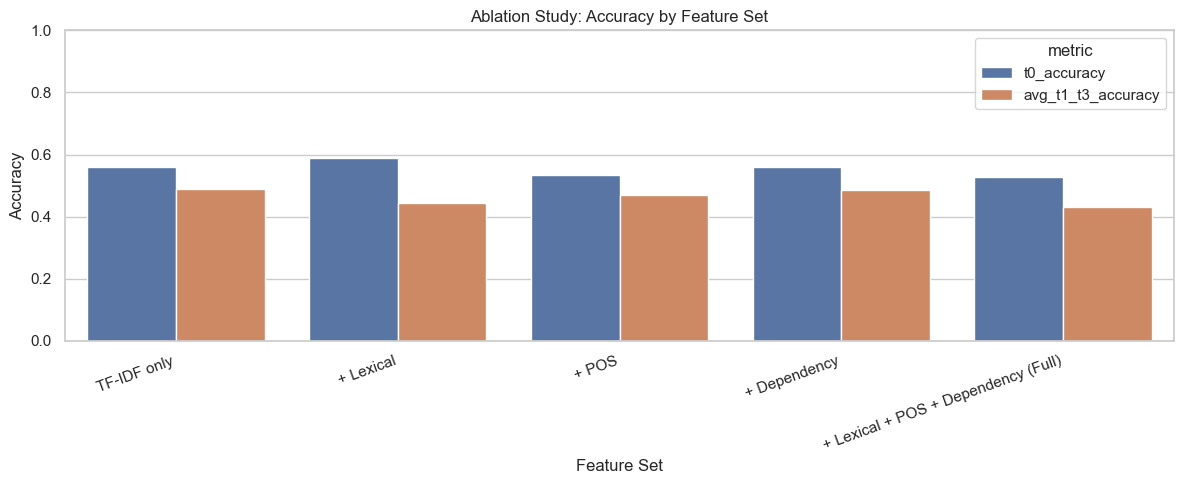

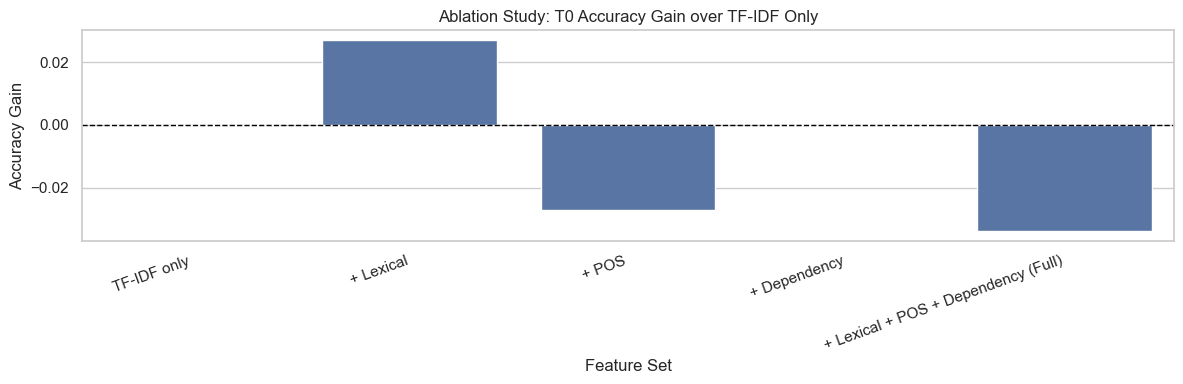

In [28]:
### Additional Tests: Compare Features (TTR, word length, punct ratio; POS tag, Dependency) and their contribution
### These features are what we already have, so it's nice to do a full fledged comparision.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Feature groups from earlier Task 2 cells
lex_t0_cols = ["ref_tok_len", "ref_ttr", "ref_avg_word_len", "ref_punct_ratio"]
lex_cand_cols = ["cand_tok_len", "cand_ttr", "cand_avg_word_len", "cand_punct_ratio"]
pos_t0_cols = [f"T0_{tag}" for tag in POS_TAGS]
pos_cand_cols = [f"cand_{tag}" for tag in POS_TAGS]
dep_t0_cols = ["T0_dep_depth"]
dep_cand_cols = ["cand_dep_depth"]


def collect_style_cols(use_lex=False, use_pos=False, use_dep=False):
    t0_cols, cand_cols = [], []
    if use_lex:
        t0_cols.extend(lex_t0_cols)
        cand_cols.extend(lex_cand_cols)
    if use_pos:
        t0_cols.extend(pos_t0_cols)
        cand_cols.extend(pos_cand_cols)
    if use_dep:
        t0_cols.extend(dep_t0_cols)
        cand_cols.extend(dep_cand_cols)
    return t0_cols, cand_cols


# Configurations for ablation
ablation_configs = [
    {
        "name": "TF-IDF only",
        "use_tfidf": True,
        "use_lex": False,
        "use_pos": False,
        "use_dep": False,
    },
    {
        "name": "+ Lexical",
        "use_tfidf": True,
        "use_lex": True,
        "use_pos": False,
        "use_dep": False,
    },
    {
        "name": "+ POS",
        "use_tfidf": True,
        "use_lex": False,
        "use_pos": True,
        "use_dep": False,
    },
    {
        "name": "+ Dependency",
        "use_tfidf": True,
        "use_lex": False,
        "use_pos": False,
        "use_dep": True,
    },
    {
        "name": "+ Lexical + POS + Dependency (Full)",
        "use_tfidf": True,
        "use_lex": True,
        "use_pos": True,
        "use_dep": True,
    },
]

# Use the same split across all ablations for fair comparison
y_all = df_t0["source"].astype(str).to_numpy()
all_idx = np.arange(len(df_t0))
train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.3,
    random_state=42,
    stratify=y_all,
)

# Source lookup for depth-wise attribution
source_lookup = df_t0[["key", "source"]].drop_duplicates(subset=["key"])


def build_t0_matrix(cfg):
    parts = []

    if cfg["use_tfidf"]:
        X_text = tfidf.transform(df_t0["text_cleaned"].astype(str))
        parts.append(X_text)

    t0_cols, cand_cols = collect_style_cols(
        use_lex=cfg["use_lex"],
        use_pos=cfg["use_pos"],
        use_dep=cfg["use_dep"],
    )

    scaler = None
    if t0_cols:
        t0_style = (
            df_t0[t0_cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0.0)
            .to_numpy(dtype=float)
        )
        scaler = StandardScaler()
        X_style = csr_matrix(scaler.fit_transform(t0_style))
        parts.append(X_style)

    if len(parts) == 1:
        X = parts[0]
    else:
        X = hstack(parts, format="csr")

    return X, scaler, cand_cols


def build_depth_matrix(depth, cfg, scaler, cand_cols):
    df_depth = eval_pairs[eval_pairs["depth"] == depth].copy()
    df_depth = df_depth.merge(source_lookup, on="key", how="left")
    df_depth = df_depth.dropna(subset=["source"])

    parts = []

    if cfg["use_tfidf"]:
        X_text = tfidf.transform(df_depth["text_cleaned"].astype(str))
        parts.append(X_text)

    if cand_cols:
        depth_style = (
            df_depth[cand_cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0.0)
            .to_numpy(dtype=float)
        )
        X_style = csr_matrix(scaler.transform(depth_style))
        parts.append(X_style)

    if len(parts) == 1:
        X = parts[0]
    else:
        X = hstack(parts, format="csr")

    y = df_depth["source"].astype(str).to_numpy()
    return X, y


ablation_rows = []

for cfg in ablation_configs:
    X_t0_cfg, scaler_cfg, cand_cols_cfg = build_t0_matrix(cfg)

    X_train_cfg = X_t0_cfg[train_idx]
    X_test_cfg = X_t0_cfg[test_idx]
    y_train_cfg = y_all[train_idx]
    y_test_cfg = y_all[test_idx]

    clf = LinearSVC(C=1.0, max_iter=2000, random_state=42)
    clf.fit(X_train_cfg, y_train_cfg)

    t0_acc = accuracy_score(y_test_cfg, clf.predict(X_test_cfg))

    depth_acc = {}
    for d in [1, 2, 3]:
        X_d, y_d = build_depth_matrix(d, cfg, scaler_cfg, cand_cols_cfg)
        depth_acc[d] = accuracy_score(y_d, clf.predict(X_d))

    ablation_rows.append(
        {
            "feature_set": cfg["name"],
            "n_features": int(X_t0_cfg.shape[1]),
            "t0_accuracy": float(t0_acc),
            "t1_accuracy": float(depth_acc[1]),
            "t2_accuracy": float(depth_acc[2]),
            "t3_accuracy": float(depth_acc[3]),
            "avg_t1_t3_accuracy": float(
                np.mean([depth_acc[1], depth_acc[2], depth_acc[3]])
            ),
        }
    )

ablation_df = pd.DataFrame(ablation_rows)

baseline_row = ablation_df[ablation_df["feature_set"] == "TF-IDF only"].iloc[0]
ablation_df["delta_t0_vs_tfidf"] = (
    ablation_df["t0_accuracy"] - baseline_row["t0_accuracy"]
)
ablation_df["delta_avg_t1_t3_vs_tfidf"] = (
    ablation_df["avg_t1_t3_accuracy"] - baseline_row["avg_t1_t3_accuracy"]
)

print("Ablation Study (accuracy contribution by feature family):")
display(ablation_df)

# Save for report integration
ablation_df.to_csv("feature_ablation_results.csv", index=False)
print("Saved: feature_ablation_results.csv")

# Visual comparison
plot_df = ablation_df.copy()
plot_df_melt = plot_df.melt(
    id_vars=["feature_set"],
    value_vars=["t0_accuracy", "avg_t1_t3_accuracy"],
    var_name="metric",
    value_name="accuracy",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df_melt, x="feature_set", y="accuracy", hue="metric")
plt.title("Ablation Study: Accuracy by Feature Set")
plt.xlabel("Feature Set")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.barplot(data=ablation_df, x="feature_set", y="delta_t0_vs_tfidf", color="#4C72B0")
plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.title("Ablation Study: T0 Accuracy Gain over TF-IDF Only")
plt.xlabel("Feature Set")
plt.ylabel("Accuracy Gain")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [29]:
### Additional Tests: A Novel Bag of Features (vocab size, perplexity, rare word ratio) and their contribution
### Idea drawn from: Arxiv 2601.12946
### Test on T0 and T1 only.


import re
import numpy as np
import pandas as pd
from collections import Counter
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# T0 base table from Task 3 prep cell; this preserves label alignment with previous experiments
df_t0_base = df_t0.copy()

# T1 evaluation set with source labels (from original T0 keys)
source_lookup = df_t0_base[["key", "source"]].drop_duplicates(subset=["key"])
df_t1_eval = eval_pairs[eval_pairs["depth"] == 1].copy()
df_t1_eval = df_t1_eval.merge(source_lookup, on="key", how="left").dropna(
    subset=["source"]
)

# Immutable split for this experiment
y_all_new = df_t0_base["source"].astype(str).to_numpy()
all_idx_new = np.arange(len(df_t0_base))
train_idx_new, test_idx_new = train_test_split(
    all_idx_new,
    test_size=0.3,
    random_state=42,
    stratify=y_all_new,
)

df_t0_train = df_t0_base.iloc[train_idx_new].copy()
df_t0_test = df_t0_base.iloc[test_idx_new].copy()

# Fit TF-IDF ONLY on this experiment's training split (immutable pipeline)
tfidf_new = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 4),
    max_features=5000,
    sublinear_tf=True,
)
tfidf_new.fit(df_t0_train["text_cleaned"].astype(str))

# Build a simple Laplace-smoothed bigram LM from T0 training texts
word_pattern = re.compile(r"[a-z0-9']+")


def tokenize(text):
    return word_pattern.findall(str(text).lower())


unigram_counts = Counter()
bigram_counts = Counter()
for txt in df_t0_train["text_cleaned"].astype(str):
    toks = tokenize(txt)
    unigram_counts.update(toks)
    bigram_counts.update(zip(toks[:-1], toks[1:]))

vocab = set(unigram_counts.keys())
V = max(len(vocab), 1)
rare_vocab = {w for w, c in unigram_counts.items() if c <= 2}


def text_extra_features(text):
    toks = tokenize(text)
    n = len(toks)

    # 1) Vocabulary size inside the text
    vocab_size = float(len(set(toks)))

    # 2) Bigram perplexity with add-one smoothing
    if n < 2:
        perplexity = 1.0
    else:
        log_prob = 0.0
        steps = 0
        for w_prev, w_cur in zip(toks[:-1], toks[1:]):
            p = (bigram_counts[(w_prev, w_cur)] + 1.0) / (unigram_counts[w_prev] + V)
            log_prob += np.log(p)
            steps += 1
        perplexity = float(np.exp(-log_prob / max(steps, 1)))

    # 3) Rare-word ratio (rarity defined on T0 training corpus)
    rare_ratio = float(sum(1 for t in toks if t in rare_vocab) / max(n, 1))

    return np.array([vocab_size, perplexity, rare_ratio], dtype=float)


new_feat_names = ["vocab_size", "bigram_perplexity", "rare_word_ratio"]
lex_t0_cols = ["ref_tok_len", "ref_ttr", "ref_avg_word_len", "ref_punct_ratio"]
lex_t1_cols = ["cand_tok_len", "cand_ttr", "cand_avg_word_len", "cand_punct_ratio"]


def build_aug_matrix(df_sub, lexical_cols, scaler=None, fit_scaler=False):
    x_text = tfidf_new.transform(df_sub["text_cleaned"].astype(str))

    x_lex = (
        df_sub[lexical_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .to_numpy(dtype=float)
    )
    x_extra = np.vstack(
        df_sub["text_cleaned"].astype(str).apply(text_extra_features).to_numpy()
    )
    x_dense = np.hstack([x_lex, x_extra])

    if fit_scaler:
        scaler = StandardScaler()
        scaler.fit(x_dense)

    x_dense_scaled = csr_matrix(scaler.transform(x_dense))
    x_all = hstack([x_text, x_dense_scaled], format="csr")
    return x_all, scaler


# Train/test matrices for T0
X_train_new, scaler_new = build_aug_matrix(
    df_t0_train, lexical_cols=lex_t0_cols, scaler=None, fit_scaler=True
)
X_test_new, _ = build_aug_matrix(
    df_t0_test, lexical_cols=lex_t0_cols, scaler=scaler_new, fit_scaler=False
)

# T1 matrix
X_t1_new, _ = build_aug_matrix(
    df_t1_eval, lexical_cols=lex_t1_cols, scaler=scaler_new, fit_scaler=False
)

y_train_new = df_t0_train["source"].astype(str).to_numpy()
y_test_new = df_t0_test["source"].astype(str).to_numpy()
y_t1_new = df_t1_eval["source"].astype(str).to_numpy()

# New immutable SVM for this update
svm_author_newfeat = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_author_newfeat.fit(X_train_new, y_train_new)

y_pred_t0_new = svm_author_newfeat.predict(X_test_new)
y_pred_t1_new = svm_author_newfeat.predict(X_t1_new)

rep_t0_new = classification_report(
    y_test_new, y_pred_t0_new, output_dict=True, zero_division=0
)
rep_t1_new = classification_report(
    y_t1_new, y_pred_t1_new, output_dict=True, zero_division=0
)

task3_newfeat_results = pd.DataFrame(
    [
        {
            "experiment": "TF-IDF+Lexical+NewFeatures",
            "stage": "T0",
            "accuracy": float(accuracy_score(y_test_new, y_pred_t0_new)),
            "macro_precision": float(rep_t0_new["macro avg"]["precision"]),
            "macro_recall": float(rep_t0_new["macro avg"]["recall"]),
            "macro_f1": float(rep_t0_new["macro avg"]["f1-score"]),
            "n_samples": int(len(y_test_new)),
        },
        {
            "experiment": "TF-IDF+Lexical+NewFeatures",
            "stage": "T1",
            "accuracy": float(accuracy_score(y_t1_new, y_pred_t1_new)),
            "macro_precision": float(rep_t1_new["macro avg"]["precision"]),
            "macro_recall": float(rep_t1_new["macro avg"]["recall"]),
            "macro_f1": float(rep_t1_new["macro avg"]["f1-score"]),
            "n_samples": int(len(y_t1_new)),
        },
    ]
)

print("New features added:", new_feat_names)
print(
    f"Feature dimensions (train): TF-IDF {tfidf_new.transform(df_t0_train['text_cleaned'].astype(str)).shape[1]} + dense {len(lex_t0_cols) + len(new_feat_names)}"
)
print("\nAdditional Ablation Study 1 results (T0/T1):")
display(task3_newfeat_results)

New features added: ['vocab_size', 'bigram_perplexity', 'rare_word_ratio']
Feature dimensions (train): TF-IDF 5000 + dense 7

Additional Ablation Study 1 results (T0/T1):


,experiment,stage,accuracy,macro_precision,macro_recall,macro_f1,n_samples
0,TF-IDF+Lexical+NewFeatures,T0,0.554054,0.610062,0.551129,0.533931,148
1,TF-IDF+Lexical+NewFeatures,T1,0.459776,0.596686,0.454873,0.461748,1964


In [30]:
### Additional Tests: SVM on BERT Embeddings
### The idea arises natually from the function of BERT of making embbeding a usable feature.
### Tested on T0 and T1 only


import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from transformers import AutoTokenizer, AutoModel

# Build T0/T1 datasets for this immutable experiment
df_t0_bert = df_t0.copy()
source_lookup_bert = df_t0_bert[["key", "source"]].drop_duplicates(subset=["key"])
df_t1_bert = eval_pairs[eval_pairs["depth"] == 1].copy()
df_t1_bert = df_t1_bert.merge(source_lookup_bert, on="key", how="left").dropna(
    subset=["source"]
)

y_all_bert = df_t0_bert["source"].astype(str).to_numpy()
all_idx_bert = np.arange(len(df_t0_bert))
train_idx_bert, test_idx_bert = train_test_split(
    all_idx_bert,
    test_size=0.3,
    random_state=42,
    stratify=y_all_bert,
)

df_t0_train_bert = df_t0_bert.iloc[train_idx_bert].copy()
df_t0_test_bert = df_t0_bert.iloc[test_idx_bert].copy()

# BERT encoder (separate from all prior models)
bert_model_name = "bert-base-uncased"
bert_device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {bert_model_name} on {bert_device}...")
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name).to(bert_device)
bert_model.eval()


def encode_with_bert(texts, batch_size=32, max_length=256):
    embs = []
    texts = [str(t) for t in texts]

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        tokens = bert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        tokens = {k: v.to(bert_device) for k, v in tokens.items()}

        with torch.no_grad():
            out = bert_model(**tokens).last_hidden_state
            mask = tokens["attention_mask"].unsqueeze(-1)
            pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            embs.append(pooled.cpu().numpy())

    return np.vstack(embs)


# Encode T0 train/test and T1
X_train_bert = encode_with_bert(df_t0_train_bert["text_cleaned"].astype(str).tolist())
X_test_bert = encode_with_bert(df_t0_test_bert["text_cleaned"].astype(str).tolist())
X_t1_bert = encode_with_bert(df_t1_bert["text_cleaned"].astype(str).tolist())

y_train_bert = df_t0_train_bert["source"].astype(str).to_numpy()
y_test_bert = df_t0_test_bert["source"].astype(str).to_numpy()
y_t1_bert = df_t1_bert["source"].astype(str).to_numpy()

# Standardize embeddings before SVM
scaler_bert = StandardScaler()
X_train_bert_scaled = scaler_bert.fit_transform(X_train_bert)
X_test_bert_scaled = scaler_bert.transform(X_test_bert)
X_t1_bert_scaled = scaler_bert.transform(X_t1_bert)

# New immutable SVM for this update
svm_author_bert = LinearSVC(C=1.0, max_iter=4000, random_state=42)
svm_author_bert.fit(X_train_bert_scaled, y_train_bert)

y_pred_t0_bert = svm_author_bert.predict(X_test_bert_scaled)
y_pred_t1_bert = svm_author_bert.predict(X_t1_bert_scaled)

rep_t0_bert = classification_report(
    y_test_bert, y_pred_t0_bert, output_dict=True, zero_division=0
)
rep_t1_bert = classification_report(
    y_t1_bert, y_pred_t1_bert, output_dict=True, zero_division=0
)

task3_bert_results = pd.DataFrame(
    [
        {
            "experiment": "BERT-Embeddings-SVM",
            "stage": "T0",
            "accuracy": float(accuracy_score(y_test_bert, y_pred_t0_bert)),
            "macro_precision": float(rep_t0_bert["macro avg"]["precision"]),
            "macro_recall": float(rep_t0_bert["macro avg"]["recall"]),
            "macro_f1": float(rep_t0_bert["macro avg"]["f1-score"]),
            "n_samples": int(len(y_test_bert)),
        },
        {
            "experiment": "BERT-Embeddings-SVM",
            "stage": "T1",
            "accuracy": float(accuracy_score(y_t1_bert, y_pred_t1_bert)),
            "macro_precision": float(rep_t1_bert["macro avg"]["precision"]),
            "macro_recall": float(rep_t1_bert["macro avg"]["recall"]),
            "macro_f1": float(rep_t1_bert["macro avg"]["f1-score"]),
            "n_samples": int(len(y_t1_bert)),
        },
    ]
)

print(f"Embedding dimension: {X_train_bert.shape[1]}")
print("\nAdditional Ablation Study 2 results (T0/T1):")
display(task3_bert_results)

Loading bert-base-uncased on cuda...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3534.67it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 768

Additional Ablation Study 2 results (T0/T1):


,experiment,stage,accuracy,macro_precision,macro_recall,macro_f1,n_samples
0,BERT-Embeddings-SVM,T0,0.506757,0.488370,0.502876,0.488283,148
1,BERT-Embeddings-SVM,T1,0.467923,0.554937,0.462503,0.464552,1964


### Paraphraser Fingerprints - Preliminary Model Identification

**Goal:** Identify which paraphrasing model (ChatGPT, Dipper, PaLM2, Pegasus) was used based on syntax and lexical diversity.

**Approach:** Train an SVM classifier to distinguish between different paraphrasing models using:
- Lexical diversity features (TTR, avg word length, etc.)
- Syntactic features (dependency tree depth, POS distributions)
- Delta features (changes from original)

We'll train on T1 data and test on T1, T2, and T3 to see if model fingerprints persist across iterations.

In [31]:
# Task 4: Prepare data for paraphraser identification
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get T1 data with model labels
df_t1 = eval_pairs[eval_pairs["depth"] == 1].copy()

print(f"T1 samples: {len(df_t1)}")
print(f"Model distribution:\n{df_t1['model_group'].value_counts()}")


# Extract comprehensive features for model identification
def extract_model_features(row):
    """Extract features that capture model-specific patterns"""
    features = []

    # Lexical features from candidate text
    features.extend(
        [
            row.get("cand_tok_len", 0),
            row.get("cand_ttr", 0),
            row.get("cand_avg_word_len", 0),
            row.get("cand_punct_ratio", 0),
        ]
    )

    # Delta features (changes from original)
    features.extend(
        [
            row.get("delta_tok_len", 0),
            row.get("delta_ttr", 0),
            row.get("delta_avg_word_len", 0),
            row.get("delta_punct_ratio", 0),
        ]
    )

    # Similarity metrics
    features.extend(
        [
            row.get("bleu", 0),
            row.get("rouge_l", 0),
            row.get("bert_score", 0),
            row.get("sbert_cosine", 0),
        ]
    )

    # POS distribution features (candidate + delta from T0)
    features.extend([row.get(f"cand_{tag}", 0) for tag in POS_TAGS])
    features.extend([row.get(f"delta_pos_{tag}", 0) for tag in POS_TAGS])

    # Dependency depth features
    features.append(row.get("cand_dep_depth", 0))
    features.append(row.get("delta_dep_depth", 0))

    return features


model_feature_cols = (
    [
        "cand_tok_len",
        "cand_ttr",
        "cand_avg_word_len",
        "cand_punct_ratio",
        "delta_tok_len",
        "delta_ttr",
        "delta_avg_word_len",
        "delta_punct_ratio",
        "bleu",
        "rouge_l",
        "bert_score",
        "sbert_cosine",
    ]
    + [f"cand_pos_{tag}" for tag in POS_TAGS]
    + [f"delta_pos_{tag}" for tag in POS_TAGS]
    + [
        "cand_dep_depth",
        "delta_dep_depth",
    ]
)

print("\nExtracting model fingerprint features for T1...")
t1_features = df_t1.apply(extract_model_features, axis=1)
t1_feature_df = pd.DataFrame(
    t1_features.tolist(),
    columns=model_feature_cols,
)
t1_feature_df["model_group"] = df_t1["model_group"].values
t1_feature_df["key"] = df_t1["key"].values

# Remove any rows with NaN values
t1_feature_df = t1_feature_df.dropna()

print(f"\nFeature matrix shape: {t1_feature_df.shape}")
print(
    f"Features: {[c for c in t1_feature_df.columns if c not in ['key', 'model_group']]}"
)

display(t1_feature_df.head())
display(t1_feature_df.describe())

T1 samples: 1964
Model distribution:
model_group
palm       491
chatgpt    491
pegasus    491
dipper     491
Name: count, dtype: int64

Extracting model fingerprint features for T1...

Feature matrix shape: (1964, 40)
Features: ['cand_tok_len', 'cand_ttr', 'cand_avg_word_len', 'cand_punct_ratio', 'delta_tok_len', 'delta_ttr', 'delta_avg_word_len', 'delta_punct_ratio', 'bleu', 'rouge_l', 'bert_score', 'sbert_cosine', 'cand_pos_NOUN', 'cand_pos_VERB', 'cand_pos_ADJ', 'cand_pos_ADV', 'cand_pos_PRON', 'cand_pos_DET', 'cand_pos_ADP', 'cand_pos_NUM', 'cand_pos_CONJ', 'cand_pos_PRT', 'cand_pos_X', 'cand_pos_.', 'delta_pos_NOUN', 'delta_pos_VERB', 'delta_pos_ADJ', 'delta_pos_ADV', 'delta_pos_PRON', 'delta_pos_DET', 'delta_pos_ADP', 'delta_pos_NUM', 'delta_pos_CONJ', 'delta_pos_PRT', 'delta_pos_X', 'delta_pos_.', 'cand_dep_depth', 'delta_dep_depth']


,cand_tok_len,cand_ttr,cand_avg_word_len,cand_punct_ratio,delta_tok_len,delta_ttr,delta_avg_word_len,delta_punct_ratio,bleu,rouge_l,...,delta_pos_ADP,delta_pos_NUM,delta_pos_CONJ,delta_pos_PRT,delta_pos_X,delta_pos_.,cand_dep_depth,delta_dep_depth,model_group,key
0,36.0,0.833333,4.000000,0.021978,-95.0,0.169211,-0.083969,-0.000146,0.020384,0.247059,...,0.022812,-0.020690,-0.027586,0.009903,0.0,-0.012732,6.000000,1.111111,palm,yelp-494
1,63.0,0.793651,4.634921,0.019391,9.0,0.071429,0.097884,-0.013289,0.153295,0.319328,...,0.023214,0.000000,-0.005357,0.014286,0.0,-0.025000,3.166667,0.166667,palm,yelp-495
2,79.0,0.734177,4.683544,0.041485,6.0,-0.074042,0.587654,0.002115,0.093440,0.333333,...,-0.013357,0.000000,-0.013066,0.035424,0.0,-0.002904,5.000000,1.833333,palm,yelp-496
3,52.0,0.846154,4.884615,0.025641,15.0,-0.045738,0.262994,-0.002528,0.173562,0.426966,...,-0.000802,0.000000,0.011227,0.017241,0.0,-0.018845,2.666667,-0.133333,palm,yelp-497
4,37.0,0.918919,4.540541,0.033333,-30.0,0.157725,0.436063,0.007545,0.095921,0.438095,...,-0.006313,-0.005051,-0.032828,0.003788,0.0,0.080808,4.000000,0.666667,palm,yelp-498


,cand_tok_len,cand_ttr,cand_avg_word_len,cand_punct_ratio,delta_tok_len,delta_ttr,delta_avg_word_len,delta_punct_ratio,bleu,rouge_l,...,delta_pos_PRON,delta_pos_DET,delta_pos_ADP,delta_pos_NUM,delta_pos_CONJ,delta_pos_PRT,delta_pos_X,delta_pos_.,cand_dep_depth,delta_dep_depth
count,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,...,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000
mean,149.726578,0.704147,4.453088,0.029998,23.046334,-0.032780,0.224212,-0.002652,0.108024,0.261191,...,0.005750,0.008411,-0.001054,-0.004206,0.000375,0.003072,-0.000441,0.001280,4.372885,0.390866
std,168.427409,0.172622,0.496950,0.012033,182.044044,0.184688,0.540383,0.016634,0.177845,0.174167,...,0.039960,0.041415,0.038491,0.016207,0.024362,0.023355,0.004666,0.048005,1.135992,1.335545
min,1.000000,0.058594,3.181818,0.000000,-862.000000,-0.864249,-1.797460,-0.187262,0.000000,0.000000,...,-0.136364,-0.272727,-0.133337,-0.130435,-0.111111,-0.079012,-0.060606,-0.453947,1.000000,-9.222222
25%,56.000000,0.633043,4.106316,0.022411,-42.000000,-0.103269,-0.114524,-0.009949,0.000000,0.159824,...,-0.018195,-0.015380,-0.024360,-0.009375,-0.013347,-0.011499,0.000000,-0.020922,3.600000,-0.382937
50%,87.500000,0.733333,4.428571,0.027445,-1.000000,-0.011273,0.193026,-0.001569,0.052014,0.219409,...,0.002103,0.007823,-0.001712,0.000000,0.000000,0.000760,0.000000,0.003382,4.333333,0.371429
75%,162.000000,0.811321,4.766860,0.035012,38.000000,0.070727,0.576696,0.005594,0.123151,0.307692,...,0.027869,0.031992,0.021671,0.000000,0.015112,0.015855,0.000000,0.027342,5.000000,1.143433
max,965.000000,1.000000,10.000000,0.161491,950.000000,0.495131,6.000000,0.083118,1.000000,1.000000,...,0.230769,0.250000,0.180451,0.156250,0.166667,0.166667,0.036585,0.409091,10.000000,6.400000


Training SVM classifier for paraphraser identification...

=== T1 Paraphraser Identification Performance ===
Accuracy: 0.7119

Classification Report:
              precision    recall  f1-score   support

     chatgpt       0.70      0.80      0.74       148
      dipper       0.70      0.73      0.72       147
        palm       0.65      0.63      0.64       148
     pegasus       0.81      0.69      0.74       147

    accuracy                           0.71       590
   macro avg       0.72      0.71      0.71       590
weighted avg       0.72      0.71      0.71       590



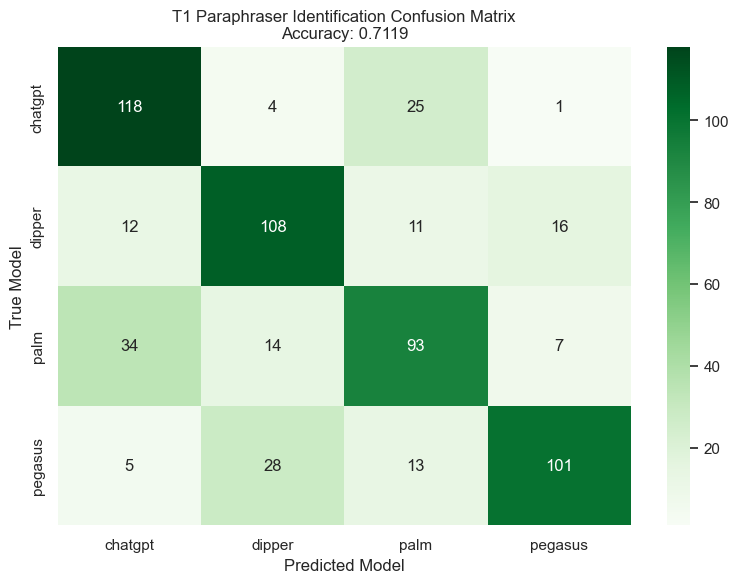


Computing feature importance...

Top 10 Most Important Features:


,feature,importance
2,cand_avg_word_len,0.083729
8,bleu,0.082542
6,delta_avg_word_len,0.046610
0,cand_tok_len,0.039492
9,rouge_l,0.038475
23,cand_pos_.,0.023559
1,cand_ttr,0.016949
3,cand_punct_ratio,0.016271
5,delta_ttr,0.015424
11,sbert_cosine,0.013559


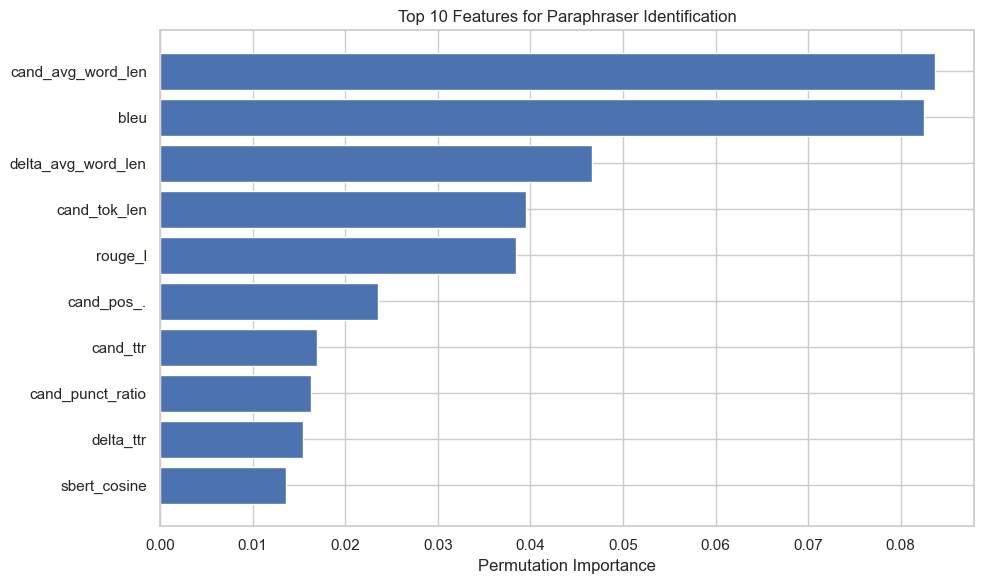

In [32]:
# Task 4: Train paraphraser identification classifier on T1

# Prepare training data
feature_cols_model = [
    c for c in t1_feature_df.columns if c not in ["key", "model_group"]
]

# ensure numeric feature matrix and numpy array labels for sklearn
X_t1 = t1_feature_df[feature_cols_model].to_numpy(dtype=float)
y_t1 = t1_feature_df["model_group"].astype(str).to_numpy()

# Split into train and test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_t1, y_t1, test_size=0.3, random_state=42, stratify=y_t1
)

# Standardize features
scaler_model = StandardScaler()
X_train_m_scaled = scaler_model.fit_transform(X_train_m)
X_test_m_scaled = scaler_model.transform(X_test_m)

# Train SVM classifier
print("Training SVM classifier for paraphraser identification...")
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_m_scaled, y_train_m)

# Evaluate on T1 test set
y_pred_m = svm_model.predict(X_test_m_scaled)
t1_model_accuracy = accuracy_score(y_test_m, y_pred_m)

print(f"\n=== T1 Paraphraser Identification Performance ===")
print(f"Accuracy: {t1_model_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_m, y_pred_m))

# Confusion matrix
cm_model = confusion_matrix(y_test_m, y_pred_m)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_model,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_,
)
plt.title(
    f"T1 Paraphraser Identification Confusion Matrix\nAccuracy: {t1_model_accuracy:.4f}"
)
plt.ylabel("True Model")
plt.xlabel("Predicted Model")
plt.tight_layout()
plt.show()

# Feature importance (using permutation importance approximation)
from sklearn.inspection import permutation_importance

print("\nComputing feature importance...")
perm_importance = permutation_importance(
    svm_model, X_test_m_scaled, y_test_m, n_repeats=10, random_state=42
)

feature_importance_df = pd.DataFrame(
    {"feature": feature_cols_model, "importance": perm_importance.importances_mean}
).sort_values("importance", ascending=False)

print("\nTop 10 Most Important Features:")
display(feature_importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df.head(10)["feature"],
    feature_importance_df.head(10)["importance"],
)
plt.xlabel("Permutation Importance")
plt.title("Top 10 Features for Paraphraser Identification")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Testing Paraphraser Identification on T1 (Depth 1)

Accuracy: 0.8121

Classification Report:
              precision    recall  f1-score   support

     chatgpt       0.80      0.88      0.83       491
      dipper       0.79      0.83      0.81       491
        palm       0.78      0.74      0.76       491
     pegasus       0.89      0.79      0.84       491

    accuracy                           0.81      1964
   macro avg       0.81      0.81      0.81      1964
weighted avg       0.81      0.81      0.81      1964



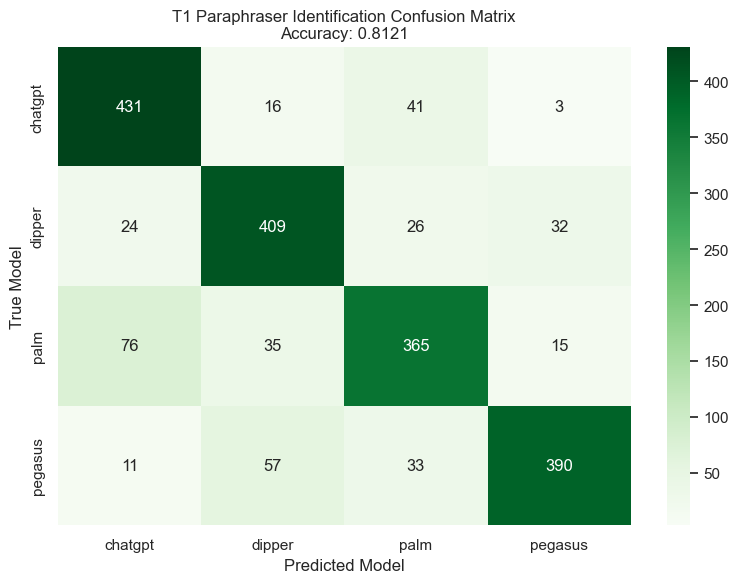


Testing Paraphraser Identification on T2 (Depth 2)

Accuracy: 0.6772
Accuracy change from T1: -0.0347

Classification Report:
              precision    recall  f1-score   support

     chatgpt       0.71      0.74      0.73       491
      dipper       0.63      0.83      0.71       491
        palm       0.66      0.72      0.69       491
     pegasus       0.77      0.42      0.54       491

    accuracy                           0.68      1964
   macro avg       0.69      0.68      0.67      1964
weighted avg       0.69      0.68      0.67      1964



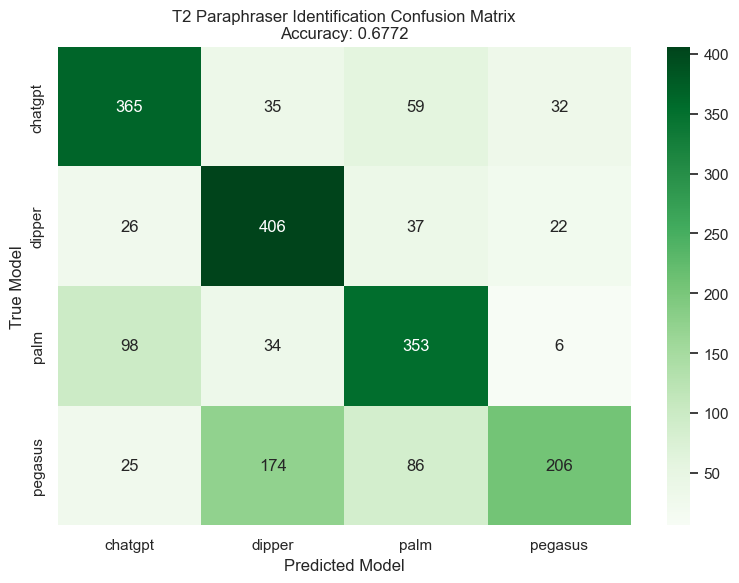


Testing Paraphraser Identification on T3 (Depth 3)

Accuracy: 0.6848
Accuracy change from T1: -0.0270

Classification Report:
              precision    recall  f1-score   support

     chatgpt       0.71      0.78      0.74       491
      dipper       0.63      0.84      0.72       491
        palm       0.65      0.72      0.69       491
     pegasus       0.85      0.41      0.55       491

    accuracy                           0.68      1964
   macro avg       0.71      0.68      0.67      1964
weighted avg       0.71      0.68      0.67      1964



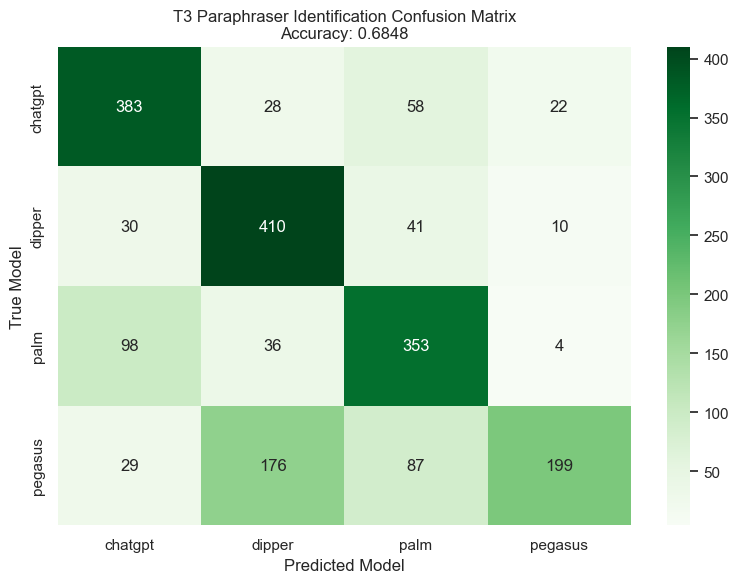


SUMMARY: Paraphraser Identification Accuracy Across Depths


,depth,stage,accuracy,accuracy_change
0,1,T1,0.812118,0.000000
1,2,T2,0.677189,-0.034675
2,3,T3,0.684827,-0.027038


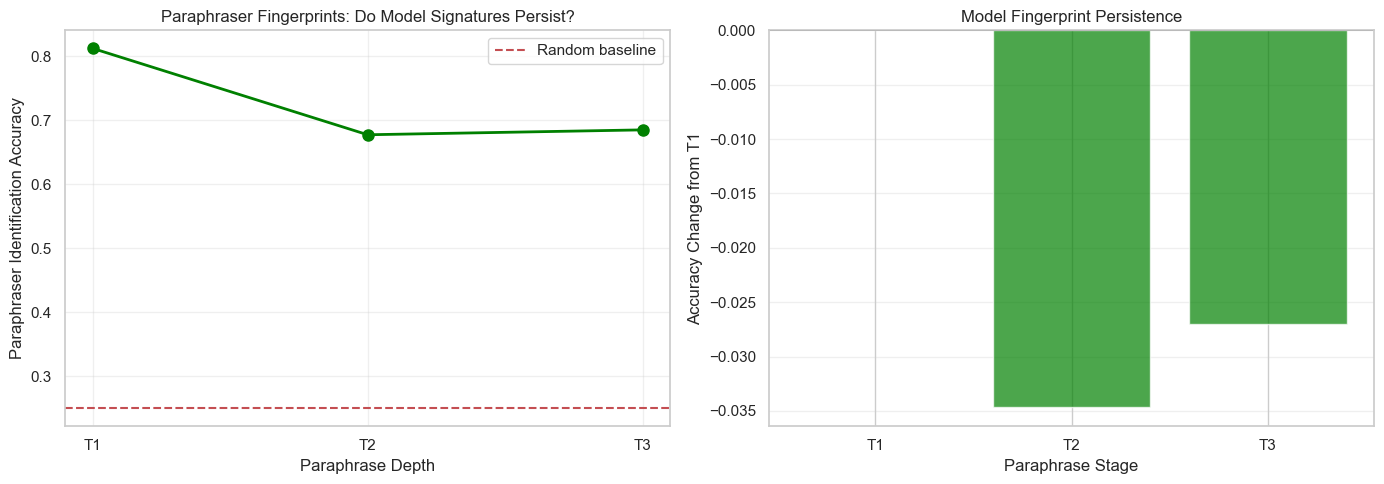

In [33]:
# Task 4: Test classifier on T2 and T3 to see if fingerprints persist


def prepare_model_features_for_depth(depth):
    """Extract model identification features for texts at a given depth"""
    df_depth = eval_pairs[eval_pairs["depth"] == depth].copy()

    features = df_depth.apply(extract_model_features, axis=1)
    feature_df = pd.DataFrame(features.tolist(), columns=feature_cols_model)
    feature_df["model_group"] = df_depth["model_group"].values
    feature_df["key"] = df_depth["key"].values

    # Remove any rows with NaN values
    feature_df = feature_df.dropna()

    return feature_df


# Test on each depth
model_results = []

for depth in [1, 2, 3]:
    print(f"\n{'='*60}")
    print(f"Testing Paraphraser Identification on T{depth} (Depth {depth})")
    print(f"{'='*60}")

    depth_features = prepare_model_features_for_depth(depth)

    X_depth_m = depth_features[feature_cols_model].values
    y_depth_m = depth_features["model_group"].values

    # Standardize using the same scaler
    X_depth_m_scaled = scaler_model.transform(X_depth_m)

    # Predict
    y_pred_depth_m = svm_model.predict(X_depth_m_scaled)
    accuracy_depth_m = accuracy_score(y_depth_m, y_pred_depth_m)

    print(f"\nAccuracy: {accuracy_depth_m:.4f}")
    if depth > 1:
        print(f"Accuracy change from T1: {(accuracy_depth_m - t1_model_accuracy):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_depth_m, y_pred_depth_m))

    # Store results
    model_results.append(
        {
            "depth": depth,
            "stage": f"T{depth}",
            "accuracy": accuracy_depth_m,
            "accuracy_change": (
                accuracy_depth_m - t1_model_accuracy if depth > 1 else 0.0
            ),
        }
    )

    # Confusion matrix
    cm_depth = confusion_matrix(y_depth_m, y_pred_depth_m)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_depth,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=svm_model.classes_,
        yticklabels=svm_model.classes_,
    )
    plt.title(
        f"T{depth} Paraphraser Identification Confusion Matrix\nAccuracy: {accuracy_depth_m:.4f}"
    )
    plt.ylabel("True Model")
    plt.xlabel("Predicted Model")
    plt.tight_layout()
    plt.show()

# Summary
model_results_df = pd.DataFrame(model_results)

print(f"\n{'='*60}")
print("SUMMARY: Paraphraser Identification Accuracy Across Depths")
print(f"{'='*60}")
display(model_results_df)

# Plot accuracy across depths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy over depth
ax1.plot(
    model_results_df["depth"],
    model_results_df["accuracy"],
    marker="o",
    linewidth=2,
    markersize=8,
    color="green",
)
ax1.axhline(
    y=1 / len(svm_model.classes_), color="r", linestyle="--", label="Random baseline"
)
ax1.set_xlabel("Paraphrase Depth")
ax1.set_ylabel("Paraphraser Identification Accuracy")
ax1.set_title("Paraphraser Fingerprints: Do Model Signatures Persist?")
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(["T1", "T2", "T3"])
ax1.grid(alpha=0.3)
ax1.legend()

# Accuracy change from T1
ax2.bar(
    model_results_df["stage"],
    model_results_df["accuracy_change"],
    alpha=0.7,
    color="green",
)
ax2.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax2.set_xlabel("Paraphrase Stage")
ax2.set_ylabel("Accuracy Change from T1")
ax2.set_title("Model Fingerprint Persistence")
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Save results
model_results_df.to_csv("paraphraser_identification_results.csv", index=False)

#### Ablation Study

Task 4 Ablation: lexical wholesome set + similarity metrics


,feature_set,n_features,t1_accuracy,t2_accuracy,t3_accuracy,avg_t2_t3_accuracy,t1_macro_f1,t2_macro_f1,t3_macro_f1,avg_t2_t3_macro_f1,delta_t1_acc_vs_lexical,delta_avg_t2_t3_acc_vs_lexical,delta_avg_t2_t3_f1_vs_lexical
5,Lexical + All similarities,8,0.718644,0.595723,0.602342,0.599033,0.719114,0.576811,0.577512,0.577161,0.127119,0.032077,0.023569
2,Lexical + ROUGE-L,5,0.669492,0.586558,0.597251,0.591904,0.668382,0.576602,0.579396,0.577999,0.077966,0.024949,0.024407
3,Lexical + BERTScore,5,0.657627,0.584521,0.592668,0.588595,0.656943,0.572556,0.575316,0.573936,0.066102,0.021640,0.020344
4,Lexical + SBERT cosine,5,0.640678,0.575356,0.596232,0.585794,0.642719,0.566450,0.586266,0.576358,0.049153,0.018839,0.022765
1,Lexical + BLEU,5,0.672881,0.573320,0.586049,0.579684,0.675719,0.557203,0.563292,0.560248,0.081356,0.012729,0.006655
0,Lexical only,4,0.591525,0.555499,0.578411,0.566955,0.591189,0.542298,0.564887,0.553592,0.000000,0.000000,0.000000


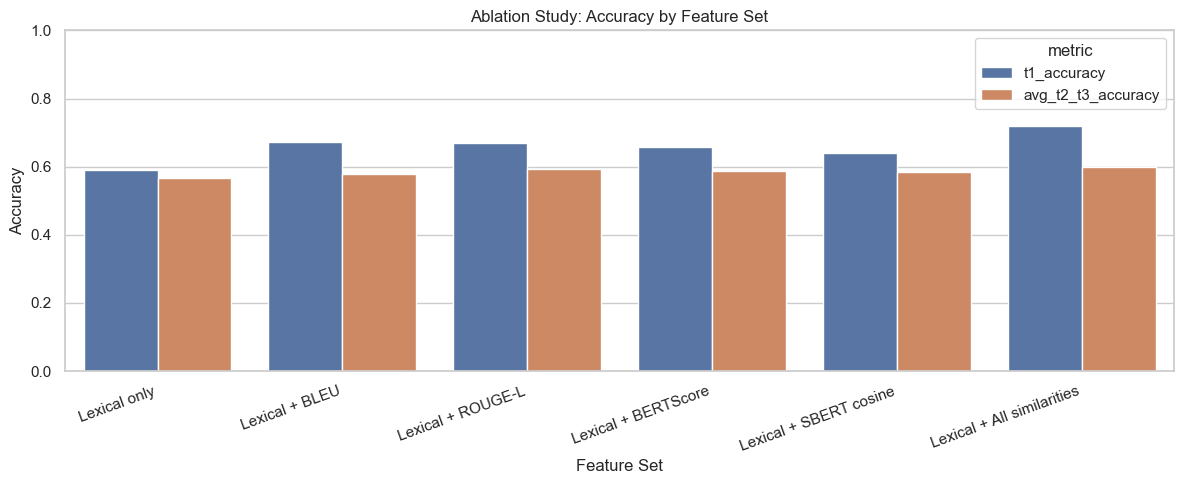

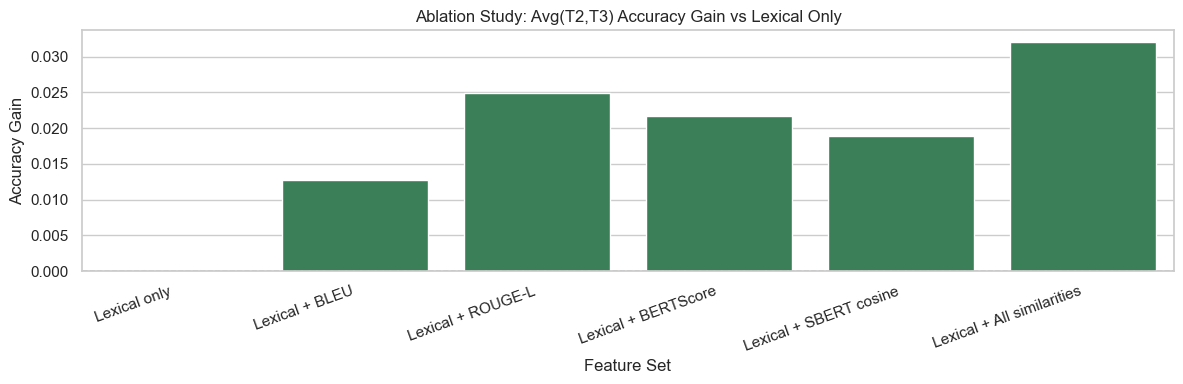

In [34]:
# Task 4 Ablation Study: lexical wholesome set vs. similarity metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Treat lexical quartet as one wholesome feature set
lexical_wholesome_cols = [
    "cand_tok_len",
    "cand_ttr",
    "cand_avg_word_len",
    "cand_punct_ratio",
]

similarity_metric_cols = {
    "BLEU": ["bleu"],
    "ROUGE-L": ["rouge_l"],
    "BERTScore": ["bert_score"],
    "SBERT cosine": ["sbert_cosine"],
}

ablation_cfgs_task4 = [
    {"name": "Lexical only", "cols": lexical_wholesome_cols},
    {
        "name": "Lexical + BLEU",
        "cols": lexical_wholesome_cols + similarity_metric_cols["BLEU"],
    },
    {
        "name": "Lexical + ROUGE-L",
        "cols": lexical_wholesome_cols + similarity_metric_cols["ROUGE-L"],
    },
    {
        "name": "Lexical + BERTScore",
        "cols": lexical_wholesome_cols + similarity_metric_cols["BERTScore"],
    },
    {
        "name": "Lexical + SBERT cosine",
        "cols": lexical_wholesome_cols + similarity_metric_cols["SBERT cosine"],
    },
    {
        "name": "Lexical + All similarities",
        "cols": lexical_wholesome_cols
        + ["bleu", "rouge_l", "bert_score", "sbert_cosine"],
    },
]

all_ablation_cols = sorted(
    set(lexical_wholesome_cols + ["bleu", "rouge_l", "bert_score", "sbert_cosine"])
)


def build_depth_master(depth):
    depth_df = eval_pairs[eval_pairs["depth"] == depth][
        ["key", "model_group"] + all_ablation_cols
    ].copy()
    depth_df = depth_df.dropna(subset=["model_group"] + all_ablation_cols)
    depth_df[all_ablation_cols] = depth_df[all_ablation_cols].apply(
        pd.to_numeric, errors="coerce"
    )
    depth_df = depth_df.dropna(subset=all_ablation_cols)
    return depth_df


t1_master = build_depth_master(1)
t2_master = build_depth_master(2)
t3_master = build_depth_master(3)

# Fixed split on T1 for fair ablation comparison
t1_idx = np.arange(len(t1_master))
y_t1_master = t1_master["model_group"].astype(str).to_numpy()
train_idx_t1, test_idx_t1 = train_test_split(
    t1_idx,
    test_size=0.3,
    random_state=42,
    stratify=y_t1_master,
)

rows_task4_ablation = []

for cfg in ablation_cfgs_task4:
    cols = cfg["cols"]

    X_t1_train = t1_master.iloc[train_idx_t1][cols].to_numpy(dtype=float)
    y_t1_train = t1_master.iloc[train_idx_t1]["model_group"].astype(str).to_numpy()

    X_t1_test = t1_master.iloc[test_idx_t1][cols].to_numpy(dtype=float)
    y_t1_test = t1_master.iloc[test_idx_t1]["model_group"].astype(str).to_numpy()

    X_t2 = t2_master[cols].to_numpy(dtype=float)
    y_t2 = t2_master["model_group"].astype(str).to_numpy()

    X_t3 = t3_master[cols].to_numpy(dtype=float)
    y_t3 = t3_master["model_group"].astype(str).to_numpy()

    scaler = StandardScaler()
    X_t1_train_s = scaler.fit_transform(X_t1_train)
    X_t1_test_s = scaler.transform(X_t1_test)
    X_t2_s = scaler.transform(X_t2)
    X_t3_s = scaler.transform(X_t3)

    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    clf.fit(X_t1_train_s, y_t1_train)

    pred_t1 = clf.predict(X_t1_test_s)
    pred_t2 = clf.predict(X_t2_s)
    pred_t3 = clf.predict(X_t3_s)

    t1_acc = accuracy_score(y_t1_test, pred_t1)
    t2_acc = accuracy_score(y_t2, pred_t2)
    t3_acc = accuracy_score(y_t3, pred_t3)

    t1_f1 = f1_score(y_t1_test, pred_t1, average="macro", zero_division=0)
    t2_f1 = f1_score(y_t2, pred_t2, average="macro", zero_division=0)
    t3_f1 = f1_score(y_t3, pred_t3, average="macro", zero_division=0)

    rows_task4_ablation.append(
        {
            "feature_set": cfg["name"],
            "n_features": len(cols),
            "t1_accuracy": float(t1_acc),
            "t2_accuracy": float(t2_acc),
            "t3_accuracy": float(t3_acc),
            "avg_t2_t3_accuracy": float(np.mean([t2_acc, t3_acc])),
            "t1_macro_f1": float(t1_f1),
            "t2_macro_f1": float(t2_f1),
            "t3_macro_f1": float(t3_f1),
            "avg_t2_t3_macro_f1": float(np.mean([t2_f1, t3_f1])),
        }
    )

task4_ablation_df = pd.DataFrame(rows_task4_ablation)

baseline_row = task4_ablation_df[
    task4_ablation_df["feature_set"] == "Lexical only"
].iloc[0]
task4_ablation_df["delta_t1_acc_vs_lexical"] = (
    task4_ablation_df["t1_accuracy"] - baseline_row["t1_accuracy"]
)
task4_ablation_df["delta_avg_t2_t3_acc_vs_lexical"] = (
    task4_ablation_df["avg_t2_t3_accuracy"] - baseline_row["avg_t2_t3_accuracy"]
)
task4_ablation_df["delta_avg_t2_t3_f1_vs_lexical"] = (
    task4_ablation_df["avg_t2_t3_macro_f1"] - baseline_row["avg_t2_t3_macro_f1"]
)

print("Task 4 Ablation: lexical wholesome set + similarity metrics")
display(task4_ablation_df.sort_values("avg_t2_t3_accuracy", ascending=False))

task4_ablation_df.to_csv("feature_ablation_results.csv", index=False)

plot_df = task4_ablation_df.melt(
    id_vars=["feature_set"],
    value_vars=["t1_accuracy", "avg_t2_t3_accuracy"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="feature_set", y="value", hue="metric")
plt.title("Ablation Study: Accuracy by Feature Set")
plt.xlabel("Feature Set")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.barplot(
    data=task4_ablation_df,
    x="feature_set",
    y="delta_avg_t2_t3_acc_vs_lexical",
    color="#2E8B57",
)
plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.title("Ablation Study: Avg(T2,T3) Accuracy Gain vs Lexical Only")
plt.xlabel("Feature Set")
plt.ylabel("Accuracy Gain")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Conclusion of Part 2

#### Point of No Return
We trained an SVM classifier to identify the original author (Human vs. AI sources) based on stylistic features. By testing on paraphrased texts at T1, T2, and T3, we determined at which iteration the original authorship signal becomes undetectable (accuracy drops to near-random).

#### Paraphraser Fingerprints
We trained an SVM classifier to identify which paraphrasing model was used (ChatGPT, Dipper, PaLM2, Pegasus) based on lexical diversity, syntactic patterns, and delta features. Testing across T1, T2, and T3 revealed whether model-specific fingerprints persist through multiple paraphrase iterations.

#### Short Intepretation
- SVM is well-suited for both tasks as it can handle high-dimensional feature spaces and non-linear decision boundaries
- Lexical and syntactic features provide strong signals for both authorship and model identification
- The persistence (or decay) of these signals across iterations reveals important insights about the "stylistic DNA" of texts